# ARI variables : date offset

In [1]:
import pandas as pd

In [2]:
[i for i in range(2, 12+2, 2)]

[2, 4, 6, 8, 10, 12]

In [3]:
# running the whole notebook for each value in the previous list to get a new dataframe for a specific time frame

In [4]:
months_offset = 0

In [5]:
date_min = pd.to_datetime('2016-09-04 21:15:19')
date_max = pd.to_datetime('2018-10-17 17:30:18')

In [6]:
limit_date = date_max - pd.DateOffset(months=months_offset)

date_min_strf = date_min.strftime('%Y-%m-%d')
limit_date_strf = limit_date.strftime('%Y-%m-%d')

csv_export_name = f'customers_{date_min_strf}_{limit_date_strf}'

In [7]:
print(date_min)
print(date_max)
print(limit_date)
print(csv_export_name)

2016-09-04 21:15:19
2018-10-17 17:30:18
2018-10-17 17:30:18
customers_2016-09-04_2018-10-17


# Imports

In [8]:
#pip freeze > requirements.txt

In [9]:
%load_ext autoreload
%autoreload 2

In [322]:
import os

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from olist.data import Olist

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

#from imblearn.over_sampling import SMOTENC

In [11]:
#from sklearn.feature_selection import VarianceThreshold
#from sklearn.decomposition import PCA

In [12]:
#data = Olist().get_data()
data = Olist().get_data()

In [13]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [14]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Exploratory Analysis

## - Run an exploratory analysis with [pandas profiling](https://github.com/pandas-profiling/pandas-profiling)

In [15]:
#! pip install pandas-profiling

In [16]:
# create a new "/reports" folder 
!mkdir -p data/reports

La syntaxe de la commande n'est pas correcte.


In [17]:
list_datas = list(data.keys())
list_datas

['customers',
 'product_category_name_translation',
 'order_items',
 'order_payments',
 'orders',
 'state_codes',
 'products',
 'geolocation',
 'order_reviews',
 'sellers']

In [18]:
#import pandas_profiling
#datasets_to_profile = ['orders', 'products', 'sellers','customers', 'order_reviews','order_items']
datasets_to_profile = list_datas

In [19]:
#for d in datasets_to_profile:
#    print('exporting: '+d)
#    profile = data[d].profile_report(title='Report for '+d)
#    profile.to_file(output_file="data/reports/"+d+'.html');

In [20]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",71,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,2448,"['product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",1000163,5,261831,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [21]:
#dict_info_df[['columns']].style.hide_index()

In [22]:
data['geolocation'][data['geolocation'].duplicated() == True]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [23]:
# check payment types
data['order_payments']['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [24]:
# dropping nulls
#for csv in datasets_to_profile:
#    data[csv].dropna(inplace=True)

In [25]:
data['products']['product_category_name'].isnull().value_counts()

False    32341
True       610
Name: product_category_name, dtype: int64

In [26]:
data['products']['product_category_name'].fillna("unknown", inplace=True)
data['products']['product_category_name'].isnull().value_counts()

False    32951
Name: product_category_name, dtype: int64

In [27]:
# add unknown to matching table
unknown_append = {'product_category_name': 'unknown', 'product_category_name_english':'unknown'}
data['product_category_name_translation'] = data['product_category_name_translation']\
                                            .append(unknown_append, ignore_index=True)

data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [28]:
# dropping duplicates
for csv in datasets_to_profile:
    data[csv].drop(data[csv][data[csv].duplicated()].index, axis=0, inplace=True)

In [29]:
# recheck :
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",72,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,1838,"['product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",738332,5,0,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [30]:
# timestamps orders : data casting
data['orders']["order_purchase_timestamp"] = pd.to_datetime(data['orders']["order_purchase_timestamp"])
data['orders']["order_delivered_carrier_date"] = pd.to_datetime(data['orders']["order_delivered_carrier_date"])
data['orders']["order_delivered_customer_date"] = pd.to_datetime(data['orders']["order_delivered_customer_date"])
data['orders']["order_estimated_delivery_date"] = pd.to_datetime(data['orders']["order_estimated_delivery_date"])
data['order_reviews']["review_creation_date"] = pd.to_datetime(data['order_reviews']["review_creation_date"])

### Préparation ARI : cut dates

In [31]:
data['orders'].dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [32]:
print(data['orders'].shape)
print(data['orders']['order_purchase_timestamp'].min())
print(data['orders']['order_purchase_timestamp'].max())

(99441, 8)
2016-09-04 21:15:19
2018-10-17 17:30:18


In [33]:
data['order_reviews'].dtypes

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp            object
dtype: object

In [34]:
print(data['order_reviews'].shape)
print(data['order_reviews']['review_creation_date'].min())
print(data['order_reviews']['review_creation_date'].max())

(99224, 7)
2016-10-02 00:00:00
2018-08-31 00:00:00


In [35]:
#nb_groups = 8

In [36]:
#months_offset = 3

In [37]:
#max_offset = 8*3
#max_offset

In [38]:
limit_date = data['orders']['order_purchase_timestamp'].max() - pd.DateOffset(months=months_offset)
limit_date

Timestamp('2018-10-17 17:30:18')

In [39]:
# orders
data['orders'] = data['orders'][data['orders']['order_purchase_timestamp'] < limit_date]

print(data['orders'].shape)
print(data['orders']['order_purchase_timestamp'].min())
print(data['orders']['order_purchase_timestamp'].max())

(99440, 8)
2016-09-04 21:15:19
2018-10-16 20:16:02


In [40]:
# reviews
#data['order_reviews'] = data['order_reviews'][data['order_reviews']['review_creation_date'] > limit_date]

print(data['order_reviews'].shape)
print(data['order_reviews']['review_creation_date'].min())
print(data['order_reviews']['review_creation_date'].max())

(99224, 7)
2016-10-02 00:00:00
2018-08-31 00:00:00


# Feature Extraction

## - Creating an order matching table

Looking at our schema, it would be best to create a central `matching_table` that will join the most important foreign keys together, for later use

❓Create the `matching_table`, a DataFrame with the following columns (below).  
Use outer joins to make sure you don't lose any information at this stage.

In [41]:
columns_matching_table = [
    "order_id",
    "review_id",
    "customer_id",
    "product_id",
    "seller_id",
]

In [42]:
#### Select only the columns of interest in the various dataframes of interest, before proceeding to any merge

#customers = data['customers'][['customer_id', 'customer_unique_id']]
customers = data['customers']
products = data['products']
product_names = data['product_category_name_translation']
payments = data['order_payments']
geo = data['geolocation']

In [43]:
# add and check new columns
orders = data['orders']
items = data['order_items']
reviews = data['order_reviews']
sellers = data['sellers']



In [44]:
orders.shape

(99440, 8)

In [45]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super recomendo essa loja!",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [46]:
# Inspect the cardinality of each DataFrame using pd.DataFrame.shape and pd.Series.nunique()
print('orders:', orders.shape, orders.customer_id.nunique(), 'unique customer_ids, and', orders.order_id.nunique(), 'unique order_ids')
print('review: ', reviews.shape, reviews.order_id.nunique(), 'unique order_ids and', reviews.review_id.nunique(), 'unique reviews' )
print('items: ', items.shape, items.order_id.nunique(), 'unique order_ids,', items.product_id.nunique(), 
      'unique product_ids, and', items.seller_id.nunique(), 'unique seller_ids')

orders: (99440, 8) 99440 unique customer_ids, and 99440 unique order_ids
review:  (99224, 7) 98673 unique order_ids and 98410 unique reviews
items:  (112650, 7) 98666 unique order_ids, 32951 unique product_ids, and 3095 unique seller_ids


## ventes ventilées par mois

In [47]:
data['orders'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99440 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99440 non-null  object        
 1   customer_id                    99440 non-null  object        
 2   order_status                   99440 non-null  object        
 3   order_purchase_timestamp       99440 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99440 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(4)
memory usage: 6.8+ MB


In [48]:
orders_full = data['orders'].copy()
orders_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [49]:
orders_full['order_status'].value_counts()

delivered      96478
shipped         1107
canceled         624
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

In [50]:
orders_delivered = orders_full[orders_full['order_status'] == 'delivered']

In [51]:
print(orders_full["order_purchase_timestamp"].min())
print(orders_full["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2018-10-16 20:16:02


In [52]:
print((orders_full["order_purchase_timestamp"].max()))

2018-10-16 20:16:02


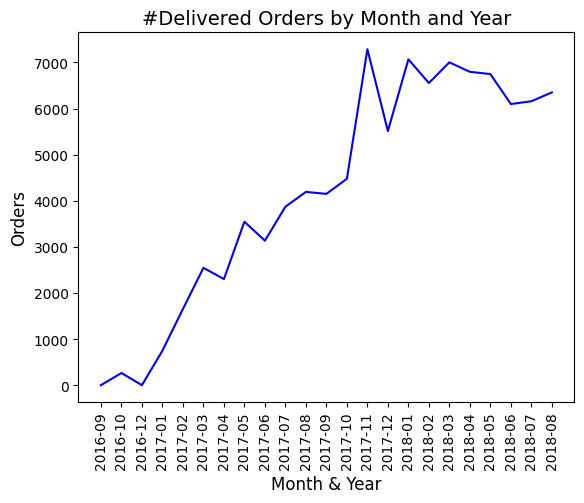

In [53]:
orders_delivered["order_purchase_timestamp"]
order_count = orders_delivered.groupby(orders_delivered["order_purchase_timestamp"].dt.to_period("M"))["order_id"].nunique()

plt.plot(order_count.index.astype(str), order_count.values, color="blue")

plt.title("#Delivered Orders by Month and Year", fontsize=14)
plt.xlabel("Month & Year", fontsize=12)
plt.ylabel("Orders", fontsize=12)

plt.xticks(rotation=90)
plt.show()

## Orders merge

In [54]:
# Carefully merge DataFrames
matching_table = orders.merge(reviews, on='order_id', how='left').merge(items, on='order_id', how='left')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.,2017-12-03,2017-12-05 19:21:58,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17,2018-02-18 13:02:51,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114086,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
114087,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
114088,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro produto.,2018-01-26,2018-01-27 09:16:56,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
114089,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro produto.,2018-01-26,2018-01-27 09:16:56,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471df

In [55]:
matching_table = orders\
        .merge(customers, on='customer_id', how='inner')\
        .merge(reviews, on="order_id", how="inner")\
        .merge(items, on="order_id", how="inner")\
        .merge(sellers, on='seller_id', how='inner')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,1ab38815794efa43d269d62b98dae815,a0b67404d84a70ef420a7f99ad6b190a,delivered,2018-07-01 10:23:10,2018-07-05 16:17:52,2018-07-04 14:34:00,2018-07-09 15:06:57,2018-07-20,2077f7ec37df79c62cc24b7b8f30e8c9,8528,ferraz de vasconcelos,SP,7f9849fcbfdf9fa3070c05b5501bf066,5,NaN,NaN,2018-07-10,2018-07-10 18:32:29,1,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2018-07-10 08:32:33,79.00,14.13,13660,porto ferreira,SP
112368,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04-01,2017-04-01 10:24:03,1,241a1ffc9cf969b27de6e72301020268,8501d82f68d23148b6d78bb7c4a42037,2017-03-16 19:51:36,19.70,10.96,89031,blumenau,SC
112369,735dce2d574afe8eb87e80a3d6229c48,d531d01affc2c55769f6b9ed410d8d3c,delivered,2018-07-24 09:46:27,2018-07-24 11:24:27,2018-07-24 15:14:00,2018-08-02 22:47:35,2018-08-16,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,60455,fortaleza,CE,19f21ead7ffe5b1b5147a7877c22bae5,5,NaN,NaN,2018-08-03,2018-08-04 11:22:40,1,1d187e8e7a30417fda31e856

In [56]:
# test get matching table
matching_table_import = Olist().get_matching_table()
matching_table_import

,customer_id,order_id,customer_unique_id,review_id,product_id,seller_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8
...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48


In [57]:
# Inspect the cardinality and `nunique` of the final DataFrame. It should match (114100, 5)
print(matching_table.shape)
print('unique values: ')
print(matching_table.nunique())

(112372, 27)
unique values: 
order_id                         97917
customer_id                      97917
order_status                         7
order_purchase_timestamp         97371
order_approved_at                89534
order_delivered_carrier_date     80450
order_delivered_customer_date    95022
order_estimated_delivery_date      450
customer_unique_id               94721
customer_zip_code_prefix         14955
customer_city                     4108
customer_state                      27
review_id                        97709
review_score                         5
review_comment_title              4497
review_comment_message           35692
review_creation_date               633
review_answer_timestamp          97547
order_item_id                       21
product_id                       32789
seller_id                         3090
shipping_limit_date              92643
price                             5948
freight_value                     6976
seller_zip_code_prefix            2

In [58]:
matching_table['order_id'].duplicated().sum()

14455

In [59]:
matching_table.loc[matching_table['order_id'].duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
57,c6094f6ab0c25eda761622ab09aa423d,69ee62ecc8d2937fca0e1a3d4de5a2ce,delivered,2018-07-25 10:16:15,2018-07-25 10:30:20,2018-07-26 14:31:00,2018-07-30 17:29:34,2018-08-22,9b82602fc3e9a153752f16553752d58d,21930,rio de janeiro,RJ,d266ab294a1fa257804bea470618c8c5,5,Perfeito!,"Adorei, os produtos chegaram bem antes do prazo, menos de uma semana, tudo bem embalado, o entregador chamou alto o q possibilita de ouvir e atender, mto bom, recomendo muito.",2018-07-31,2018-08-01 01:48:47,2,0f91b6a95a57a43203a9b17de98960d9,289cdb325fb7e7f891c38608bf9e0962,2018-07-27 10:30:20,119.30,15.93,31570,belo horizonte,SP
75,c94edffab2f10ec24645c62b40881e88,83e4193ef8adca21142f06ba078bf556,delivered,2018-08-25 14:05:07,2018-08-26 13:55:19,2018-08-27 14:36:00,2018-08-29 11:44:40,2018-09-11,3ff9132b9f4a7e46118e5347c765f77b,23035,rio de janeiro,RJ,4c9edf9090763f01b46103e2e218c926,3,NaN,NaN,2018-08-30,2018-08-30 16:53:52,2,fbc1488c1a1e72ba175f53ab29a248e8,289cdb325fb7e7f891c38608bf9e0962,2018-08-28 13:55:19,116.90,15.92,31570,belo horizonte,SP
77,d543201a9b42a1402ff97e65b439a48b,971bf8f42a9f8cb3ead257854905b454,delivered,2018-08-21 10:00:25,2018-08-21 10:50:54,2018-08-22 15:21:00,2018-08-28 18:58:22,2018-09-10,958ac7760e5484df1496ba5833ab6117,89117,gaspar,SC,8892abc02a527ef7535564ecfc0d0133,5,super recomendo,"entrega no prazo, amei",2018-08-29,2018-09-11 12:15:59,2,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-08-23 10:50:54,116.90,22.75,31570,belo horizonte,SP
80,c0fc5c6702f93ec8646c5404b4147864,6eed4ef57344486d5a44b9b8e23913c2,delivered,2018-08-20 12:14:50,2018-08-20 15:36:05,2018-08-21 14:56:00,2018-08-23 14:46:50,2018-09-04,e67ac9785a0dbbb134040135a75cdb71,22450,rio de janeiro,RJ,3353bb5244d0ae8b7a7f83c3acedc009,5,NaN,NaN,2018-08-24,2018-08-24 19:02:59,2,0f91b6a95a57a43203a9b17de98960d9,289cdb325fb7e7f891c38608bf9e0962,2018-08-22 15:35:21,116.90,15.92,31570,belo horizonte,SP
83,8ecc75b89cac1a60578b65339ad6a169,ab5e250b91db7cff17070cdf5cad37ee,delivered,2018-06-14 14:54:24,2018-06-14 15:20:30,2018-06-15 14:29:00,2018-06-20 11:35:31,2018-07-04,76355fb3e7cfd10805e28e4bfbddda37,38810,rio paranaiba,MG,2f856eb122666743526589f95a658f40,5,NaN,NaN,2018-06-21,2018-06-21 15:39:30,2,8312d7de87652a517f739c42bb4fd3f0,289cdb325fb7e7f891c38608bf9e0962,2018-06-18 15:20:30,29.90,13.55,31570,belo horizonte,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112345,c894fad29c885c81201d9bdd80cd68c5,42db86d932ba029e4e0290778ebfc59d,invoiced,2017-12-18 10:39:37,2017-12-19 09:51:49,NaT,NaT,2018-01-05,803c530613f5c4ee03502be0d6894de0,12236,sao jose dos campos,SP,a0cce310b010a5ba8531952af8d2836c,1,NaN,Não recebi o produto até o momento. Estou no aguardo de um retorno,2018-01-09,2018-01-09 03:29:32,5,0c40401eba358c9ef2ff2df80b6eab52,3bfad056cf05c00dabe2f895925d83b1,2017-12-26 09:51:49,41.33,9.34,6033,osasco,SP
112349,b6b9f5144b004ad3db40567cdce34811,8fdfa85118487910ecb24477b00c6ae3,delivered,2018-04-30 10:10:48,2018-04-30 10:31:13,2018-05-07 14:04:00,2018-05-14 16:37:46,2018-05-17,a38640e92b9b5084cad12f3f3b200a83,35057,governador valadares,MG,384e5d48af46db4c863eb5d756566368,5,NaN,😃 ótimo 👍,2018-05-15,2018-05-15 22:17:19,2,6292e8c74db1d4defdbd8244c1101bb6,a3fa18b3f688ec0fca3eb8bfcbd2d5b3,2018-05-07 10:31:02,23.90,18.23,4557,são paulo,SP
112355,d3a84031db6c5de813d5a3a3489712ca,a5bda6def3f77258ca2027b7d4a384e9,delivered,2016-10-09 23:25:13,2016-10-10 11:03:08,2016-10-14 11:03:10,2016-10-14 11:03:10,2016-11-30,ffb973f2bb1c0cb8

In [60]:
matching_table.loc[matching_table['order_id'] == 'acce194856392f074dbf9dada14d8d82']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
10565,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2d4303fd561eb4ab51c87faa6598dc10,1,NÃO RECOMENDO!!!!,"Até o momento não recebi o produto Protetor De Colchão Para Berço - Algodão Impermeável, já fiz a reclamação desde o dia 18/06 e ainda não obtive retorno. Irei cancelar o pedido e estornar a compra hj",2018-06-17,2018-06-20 11:38:22,1,d70f38e7f79c630f8ea00c993897042c,977f9f63dd360c2a32ece2f93ad6d306,2018-06-13 00:35:10,90.9,48.64,14910,tabatinga,SP
10590,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2d4303fd561eb4ab51c87faa6598dc10,1,NÃO RECOMENDO!!!!,"Até o momento não recebi o produto Protetor De Colchão Para Berço - Algodão Impermeável, já fiz a reclamação desde o dia 18/06 e ainda não obtive retorno. Irei cancelar o pedido e estornar a compra hj",2018-06-17,2018-06-20 11:38:22,2,9451e630d725c4bb7a5a206b48b99486,d673a59aac7a70d8b01e6902bf090a11,2018-06-13 00:35:10,39.5,48.64,14940,ibitinga,SP


In [61]:
products[products.product_id.isin(['977f9f63dd360c2a32ece2f93ad6d306', '977f9f63dd360c2a32ece2f93ad6d306'])]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [62]:
# check n# orders per customer

In [63]:
#orders = data['orders'][['customer_id', 'order_id']]
#customers = data['customers'][['customer_id', 'customer_unique_id']]

In [64]:
match_orders = orders.merge(customers, on='customer_id', how='left')

In [65]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [66]:
orders_count = match_orders \
                .groupby('customer_unique_id')['order_id'] \
                .nunique().reset_index(name='orders_count')

In [67]:
orders_count['count_category'] = np.where(orders_count['orders_count'] == 1, '1', '2+')

In [68]:
orders_count.sort_values(by='orders_count', ascending=False)

,customer_unique_id,orders_count,count_category
52972,8d50f5eadf50201ccdcedfb9e2ac8455,17,2+
23472,3e43e6105506432c953e165fb2acf44c,9,2+
37797,6469f99c1f9dfae7733b25662e7f1782,7,2+
76081,ca77025e7201e3b30c44b472ff346268,7,2+
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,2+
...,...,...,...
32508,5657dfebff5868c4dc7e8355fea865c4,1,1
32507,5657596addb4d7b07b32cd330614bdf8,1,1
32506,5656eb169546146caeab56c3ffc3d268,1,1
32505,5656a8fabc8629ff96b2bc14f8c09a27,1,1


In [69]:
orders_info = pd.concat([orders_count['orders_count'].value_counts(normalize=True),
                        orders_count['orders_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count customers'))
orders_info.index.name = 'orders per customer'
orders_info

,percent,count customers
orders per customer,,
1,0.968812,93098
2,0.028565,2745
3,0.002112,203
4,0.000312,30
5,0.000083,8
6,0.000062,6
7,0.000031,3
9,0.000010,1
17,0.000010,1


In [70]:
orders_info_cum = pd.concat([orders_count['count_category'].value_counts(normalize=True),
                        orders_count['count_category'].value_counts()], 
                        axis=1,
                        keys=('perc','count'))
orders_info_cum.index.name = 'orders per customer'
orders_info_cum

,perc,count
orders per customer,,
1,0.968812,93098
2+,0.031188,2997


=> ~3.12 % of the total of customers (2997 total) has made more than 1 order.

In [71]:
## selecting / merging data for clustering


In [72]:
match_orders = match_orders.merge(orders_count, on='customer_unique_id', how='left')

In [73]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,orders_count,count_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,2+
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1,1
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,1
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,1
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,1


In [74]:
## picking orders from customers_unique_id having made more than 2 orders 
match_orders_2p = match_orders[['customer_id','order_id', 'customer_unique_id']].loc[match_orders['orders_count'] > 1]
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99306,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99343,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99346,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99418,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [75]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99306,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99343,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99346,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99418,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [76]:
##  adding orders categories and reviews info

In [77]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super recomendo essa loja!",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [78]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99306,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99343,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99346,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99418,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [79]:
products = products.merge(product_names, on='product_category_name', how='left')
products = products.reindex(['product_id', 'product_category_name',  'product_category_name_english', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'], axis=1)
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [80]:
m_df = match_orders_2p \
    .merge(items[['order_id', 'product_id', 'price']], on='order_id', how='left') \
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left') \
    .merge(reviews, on='order_id', how='left')

In [81]:
m_df

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48
1,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f,009c09f439988bc06a93d6b8186dce73,132.40,perfumery,5a8608437f4b52bec5cd143f37258b5e,5.0,Nota dez,Obrigado pela atenção. Lojas lannister perfeito em tudo.,2018-07-03,2018-07-03 15:10:07
2,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5,638bbb2a5e4f360b71f332ddfebfd672,1299.00,construction_tools_construction,NaN,NaN,NaN,NaN,NaT,NaN
3,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259,c50ca07e9e4db9ea5011f06802c0aea0,14.49,health_beauty,5853e27c64b89e222c5e4edf78bec3d4,1.0,NaN,NaN,2018-07-01,2018-07-11 20:41:18
4,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514,ba4bfbf74dbe7ab37e263b9326da0523,36.90,sports_leisure,bcab37e37778893d858b3d159849a56d,4.0,NaN,NaN,2017-05-26,2017-06-01 19:10:49
...,...,...,...,...,...,...,...,...,...,...,...,...
8240,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b,f5e585e188891ed071253bacfad60820,194.80,computers_accessories,d3006c9fd3bef31b68bd680fe4098202,5.0,TAvaliação da entrega Car,Adquiri 4 cartuchos 41 Canon e recebi somente 2 até o momento.,2018-05-15,2018-05-16 04:42:04
8241,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1,d220fdef3dfe133c5a725ee59ce99595,349.90,auto,dd378bada585d0bd633bf39fc9574548,5.0,NaN,NaN,2018-03-28,2018-03-29 22:27:19
8242,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,NaN,047fd109ced39e02296f6aeb74f6a6f1,4.0,NaN,NaN,2018-07-31,2018-08-02 15:11:49
8243,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc,9e10ae46a3021a02f1692448ef9fa1db,37.90,health_beauty,47697b20bcd3995f870e284fad248ac8,4.0,NaN,NaN,2017-10-07,2017-10-09 22:28:51


In [82]:
# more rows => more items/products total than orders total (i.e. orders with multiple items)
# check out orders with multiple items to be sure it will be usable / absence of duplicates (in price for ex)

In [83]:
product_count = m_df \
                .groupby('order_id')['product_id'] \
                .nunique().reset_index(name='prod_count')
product_count.sort_values(by='prod_count', ascending=False)

,order_id,prod_count
5686,e43f88863d1cc9cff18d753d439d42e8,6
2248,5a3b1c29a49756e75f1ef513383c0c12,6
324,0c57cbfd927d9e62af8beee6d48920b7,5
5075,cc2999bc678cab0949b90c4759d7a284,4
3116,7e3fefb35b0b1d765a343618ca5d454c,4
...,...,...
4579,b90cc9e10252911c2092a1e49794aa13,0
5363,d69fcef5a5fe3a3db60ea65c6ee499cc,0
3038,7a9d4c7f9b068337875b95465330f2fc,0
6148,f81e71dd7c044a9ee7c1d6e37d68d64f,0


In [84]:
product_info = pd.concat([product_count['prod_count'].value_counts(normalize=True),
                        product_count['prod_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count orders'))
product_info.index.name = 'products per order'
product_info

,percent,count orders
products per order,,
1,0.925891,5872
2,0.047304,300
0,0.016872,107
3,0.008199,52
4,0.001261,8
6,0.000315,2
5,0.000158,1


In [85]:
# checking order 5a3b1c29a49756e75f1ef513383c0c12

#m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

# handles duplicates from matching_table (reviews...)
m_df[['product_id', 'price', 'product_category_name_english']]\
.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']\
.drop_duplicates()

,product_id,price,product_category_name_english
1415,99444c1e11fc38755dae86f5c67d3d1a,49.99,bed_bath_table
1417,17d8b8e9c21ec0fc5b33724e32fe422e,58.90,bed_bath_table
1419,399f54c06661d06ca45c6e24ed238e0e,61.90,bed_bath_table
1421,6a0713a63e990052795623e76cc2995e,72.90,bed_bath_table
1427,d25bbb182b51d1594fe3b54a27ae143e,69.90,bed_bath_table
1429,e95fb3a80ca294f39de925b6428f3a32,78.90,bed_bath_table


In [86]:
# check products
check_prod = m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5347,d25bbb182b51d1594fe3b54a27ae143e,cama_mesa_banho,bed_bath_table,34.0,308.0,1.0,1900.0,58.0,15.0,46.0
14912,6a0713a63e990052795623e76cc2995e,cama_mesa_banho,bed_bath_table,31.0,151.0,1.0,900.0,40.0,4.0,30.0
20180,17d8b8e9c21ec0fc5b33724e32fe422e,cama_mesa_banho,bed_bath_table,26.0,212.0,2.0,1000.0,30.0,4.0,40.0
25905,e95fb3a80ca294f39de925b6428f3a32,cama_mesa_banho,bed_bath_table,29.0,263.0,1.0,1300.0,33.0,9.0,38.0
29768,99444c1e11fc38755dae86f5c67d3d1a,cama_mesa_banho,bed_bath_table,40.0,162.0,1.0,900.0,33.0,9.0,38.0
30087,399f54c06661d06ca45c6e24ed238e0e,cama_mesa_banho,bed_bath_table,34.0,216.0,2.0,1100.0,33.0,9.0,38.0


In [87]:
items.loc[items['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
39679,5a3b1c29a49756e75f1ef513383c0c12,1,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39680,5a3b1c29a49756e75f1ef513383c0c12,2,17d8b8e9c21ec0fc5b33724e32fe422e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,58.90,2.66
39681,5a3b1c29a49756e75f1ef513383c0c12,3,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39682,5a3b1c29a49756e75f1ef513383c0c12,4,6a0713a63e990052795623e76cc2995e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,72.90,2.66
39683,5a3b1c29a49756e75f1ef513383c0c12,5,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39684,5a3b1c29a49756e75f1ef513383c0c12,6,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39685,5a3b1c29a49756e75f1ef513383c0c12,7,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72
39686,5a3b1c29a49756e75f1ef513383c0c12,8,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39687,5a3b1c29a49756e75f1ef513383c0c12,9,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39688,5a3b1c29a49756e75f1ef513383c0c12,10,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72


In [88]:
# checking order e43f88863d1cc9cff18d753d439d42e8
m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
4291,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,9036be77e0a74cca6eeef0740649b97b,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52
4292,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,238314b88e4b8ffa496db6b1a201d897,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52
4293,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,28447390cfd2a411fcb8c008b6163da2,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52
4294,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,2e0b9273624db778d82fd3b18becec24,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52
4295,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,8fa5bb1e4de7a63ee554487c2f2ee076,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52
4296,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,b65214d387c754bb0f858a4a5a0f41ad,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05,2018-01-05 11:46:52


In [89]:
# check products
check_prod = m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1102,28447390cfd2a411fcb8c008b6163da2,brinquedos,toys,57.0,696.0,4.0,405.0,21.0,7.0,16.0
14154,8fa5bb1e4de7a63ee554487c2f2ee076,brinquedos,toys,58.0,696.0,4.0,325.0,21.0,7.0,16.0
19331,2e0b9273624db778d82fd3b18becec24,brinquedos,toys,57.0,707.0,4.0,345.0,19.0,16.0,18.0
23282,9036be77e0a74cca6eeef0740649b97b,brinquedos,toys,57.0,697.0,3.0,405.0,21.0,7.0,15.0
24483,b65214d387c754bb0f858a4a5a0f41ad,brinquedos,toys,57.0,696.0,4.0,325.0,21.0,7.0,16.0
31683,238314b88e4b8ffa496db6b1a201d897,brinquedos,toys,56.0,696.0,4.0,300.0,21.0,7.0,16.0


In [90]:
items.loc[items['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
100670,e43f88863d1cc9cff18d753d439d42e8,1,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100671,e43f88863d1cc9cff18d753d439d42e8,2,238314b88e4b8ffa496db6b1a201d897,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100672,e43f88863d1cc9cff18d753d439d42e8,3,28447390cfd2a411fcb8c008b6163da2,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100673,e43f88863d1cc9cff18d753d439d42e8,4,2e0b9273624db778d82fd3b18becec24,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100674,e43f88863d1cc9cff18d753d439d42e8,5,8fa5bb1e4de7a63ee554487c2f2ee076,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100675,e43f88863d1cc9cff18d753d439d42e8,6,b65214d387c754bb0f858a4a5a0f41ad,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25


In [91]:
items.duplicated().sum()

0

In [92]:
# => may have to handle the "duplicate" prices not matching reality (price of the whole order for singular products)

## RFM : Recency / Frequency / Monetary values

### Préparation

In [93]:
data['orders']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [94]:
ord_time = data['orders'][['order_id','customer_id', 'order_purchase_timestamp']]
ord_time = ord_time.merge(customers, on='customer_id', how='left')\
[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
...,...,...,...
99435,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05
99436,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58
99437,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43
99438,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27


In [95]:
ord_time['order_purchase_timestamp'] = pd.to_datetime(ord_time['order_purchase_timestamp']).dt.date

In [96]:
ord_time['order_purchase_timestamp'].isnull().values.any()

False

In [97]:
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13
...,...,...,...
99435,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09
99436,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06
99437,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27
99438,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08


In [98]:
ord_time.dtypes

customer_unique_id          object
order_id                    object
order_purchase_timestamp    object
dtype: object

In [99]:
orders_price = items.groupby(['order_id']).agg('sum')
orders_price.head()

,order_item_id,price,freight_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [100]:
# rename / reorganize dataset
ord_df = ord_time.merge(orders_price, on='order_id', how='outer')
ord_df.rename({'price':'total_revenue', 'order_purchase_timestamp': 'purchase_date'}, axis='columns', inplace=True)
ord_df = ord_df[['order_id', 'customer_unique_id', 'total_revenue', 'freight_value', 'purchase_date']]
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13
...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,13.08,2017-03-09
99436,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,20.10,2018-02-06
99437,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,65.02,2017-08-27
99438,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,81.18,2018-01-08


In [101]:
orders_df_match = matching_table[['customer_unique_id', 'order_id','product_id', 'price', 'freight_value']].drop_duplicates()
orders_df_match

,customer_unique_id,order_id,product_id,price,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,8.72
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b00a32a0b42fd65efb58a5822009f629,75.90,7.79
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,725cbfcaff95a4d43742fdf13cf43c75,44.99,7.78
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,725cbfcaff95a4d43742fdf13cf43c75,44.99,7.78
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,d7faab3fa0091d1220a8ada9cae1bab3,29.90,14.10
...,...,...,...,...,...
112367,2077f7ec37df79c62cc24b7b8f30e8c9,1ab38815794efa43d269d62b98dae815,31ec3a565e06de4bdf9d2a511b822b4d,79.00,14.13
112368,78a159045124eb7601951b917a42034f,b159d0ce7cd881052da94fa165617b05,241a1ffc9cf969b27de6e72301020268,19.70,10.96
112369,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,735dce2d574afe8eb87e80a3d6229c48,1d187e8e7a30417fda31e85679d96f0f,399.00,45.07
112370,e55e436481078787e32349cee9febf5e,25d2bfa43663a23586afd12f15b542e7,6e1c2008dea1929b9b6c27fa01381e90,219.90,24.12


In [102]:
# Recency

=> To define 'Recency' we have to take into account the limit of the current dataframe, more than a min/max date, a simple analysis/display of the distribution of orders over dates would help (can cover some errors/outliers to get the general picture).

In [103]:
# check min / max dates and overall dates distribution of orders
# convert timestamp to date

In [104]:
ord_df.dtypes

order_id               object
customer_unique_id     object
total_revenue         float64
freight_value         float64
purchase_date          object
dtype: object

In [105]:
# https://practicaldatascience.co.uk/data-science/how-to-assign-rfm-scores-with-quantile-based-discretization
# => Recency is a measure of the number of days since the customer last placed an order. 

### Consolidation Dataframe RFM

In [106]:
df_customers = pd.DataFrame(ord_df['customer_unique_id'].unique())
df_customers.columns = ['customer_unique_id']
df_customers.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
1,af07308b275d755c9edb36a90c618231
2,3a653a41f6f9fc3d2a113cf8398680e8
3,7c142cf63193a1473d2e66489a9ae977
4,72632f0f9dd73dfee390c9b22eb56dd6


In [107]:
df_recency = ord_df.groupby('customer_unique_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_unique_id'
                      ,'recency_date'
                     ]
df_customers = df_customers.merge(df_recency, on='customer_unique_id')
df_customers['recency'] = round((pd.to_datetime(f'{limit_date_strf}') - pd.to_datetime(df_customers['recency_date']))\
                                / np.timedelta64(1, 'D') ).astype(int)

In [108]:
df_customers

,customer_unique_id,recency_date,recency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380
1,af07308b275d755c9edb36a90c618231,2018-07-24,85
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246
...,...,...,...
96090,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587
96091,da62f9e57a76d978d02ab5362c509660,2018-02-06,253
96092,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416
96093,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282


In [109]:
### Frequency

# Order frequency is simply the number of orders each customer has placed. 

In [110]:
df_frequency = ord_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id','frequency']
df_customers = df_customers.merge(df_frequency, on='customer_unique_id')

In [111]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96090,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96091,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96092,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96093,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [112]:
### Monetary value

# The monetary value column is the sum() of the total_revenue column for each customer. 

In [113]:
ord_df['total_revenue'].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: total_revenue, dtype: float64

In [114]:
ord_df['total_revenue'].isna().value_counts()

False    98666
True       774
Name: total_revenue, dtype: int64

In [115]:
# drop orders with no price listed
ord_df.dropna(subset=['total_revenue'], inplace=True)

ord_df['total_revenue'].isna().value_counts()

False    98666
Name: total_revenue, dtype: int64

In [116]:
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13
...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,13.08,2017-03-09
99436,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,20.10,2018-02-06
99437,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,65.02,2017-08-27
99438,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,81.18,2018-01-08


In [117]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96090,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96091,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96092,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96093,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [118]:
df_monetary = ord_df.groupby('customer_unique_id')['total_revenue'].sum().reset_index()
df_monetary.columns = ['customer_unique_id','monetary']

In [119]:
#df_monetary = custo_product_all_cat.groupby('customer_unique_id')['price'].sum().reset_index()
#df_monetary.columns = ['customer_unique_id','monetary']
df_monetary

,customer_unique_id,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00
...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00
95416,fffea47cd6d3cc0a88bd621562a9d061,64.89
95417,ffff371b4d645b6ecea244b27531430a,89.90
95418,ffff5962728ec6157033ef9805bacc48,115.00


In [120]:
df_monetary['monetary'].describe()

count    95420.000000
mean       142.440198
std        217.656355
min          0.850000
25%         47.900000
50%         89.900000
75%        155.000000
max      13440.000000
Name: monetary, dtype: float64

In [121]:
df_monetary.loc[df_monetary['monetary'] == 0]['customer_unique_id'].nunique()

0

In [122]:
# retrait des customers sans achat
df_monetary.dropna(subset=['monetary'], inplace=True)

In [123]:
mask_value = df_monetary['monetary'] == 0
df_monetary = df_monetary.loc[~mask_value]

In [124]:
df_monetary.describe()

,monetary
count,95420.000000
mean,142.440198
std,217.656355
min,0.850000
25%,47.900000
50%,89.900000
75%,155.000000
max,13440.000000


In [125]:
# not used anymore, split into multiple main categories cf "feature variance filtering"

#df_customers = df_customers.merge(df_monetary, on='customer_unique_id')

In [126]:
df_customers.drop(['recency_date'], axis=1, inplace=True)
df_customers

,customer_unique_id,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,380,2
1,af07308b275d755c9edb36a90c618231,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1
3,7c142cf63193a1473d2e66489a9ae977,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1
...,...,...,...
96090,6359f309b166b0196dbf7ad2ac62bb5a,587,1
96091,da62f9e57a76d978d02ab5362c509660,253,1
96092,737520a9aad80b3fbbdad19b66b37b30,416,1
96093,5097a5312c8b157bb7be58ae360ef43c,282,1


## Product categories

In [127]:
data['order_items']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [128]:
# check product categories
data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [129]:
# merge into general categories if possible
data['product_category_name_translation']['product_category_name_english'].sort_values(ascending=True).tolist()

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

### Reduce dimensionality


In [130]:
# initially listed as a reminder to have exhaustive lists, not used
other = [
 'auto',
 'unknown'
 ]

In [131]:
books_stationery =[
 'books_general_interest',
 'books_imported',
 'books_technical',
 'stationery'
]

electronics = [
 'electronics',
 'computers',
 'computers_accessories',
 'dvds_blu_ray',
 'fixed_telephony',
 'telephony',
 'small_appliances',
 'small_appliances_home_oven_and_coffee',
 'tablets_printing_image'
]

construction = [
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'costruction_tools_tools',
 'home_construction'
]

garden = [
 'costruction_tools_garden',
 'garden_tools'
]


fashion = [
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach'
]


furniture = [
 'bed_bath_table',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'office_furniture',
 'kitchen_dining_laundry_garden_furniture',
 'la_cuisine'
]

health_beauty = [
 'health_beauty',
 'perfumery',
 'baby',
 'diapers_and_hygiene'
]

home = [
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confort',
 'housewares',
 'flowers',
 'christmas_supplies',
 'party_supplies'
]


toys_gifts = [
 'toys',
 'watches_gifts',
 'cool_stuff'
]

sports_leisure = [
 'sports_leisure',
 'cine_photo',
 'musical_instruments',
 'art',
 'arts_and_craftmanship',
 'cds_dvds_musicals',
 'music',
 'consoles_games',
 'audio'
]

misc = [
 'agro_industry_and_commerce',
 'air_conditioning',
 'industry_commerce_and_business',
 'luggage_accessories',
 'market_place',
 'pet_shop',
 'security_and_services',
 'signaling_and_security',
 'drinks',
 'food',
 'food_drink'
 ]



In [132]:
product_names["product_global_category"] = product_names["product_category_name_english"]

In [133]:
product_names['product_global_category'] = product_names['product_global_category'].replace(books_stationery, 'books_stationery')
product_names['product_global_category'] = product_names['product_global_category'].replace(electronics, 'electronics')
product_names['product_global_category'] = product_names['product_global_category'].replace(construction, 'construction')
product_names['product_global_category'] = product_names['product_global_category'].replace(garden, 'garden')
product_names['product_global_category'] = product_names['product_global_category'].replace(fashion, 'fashion')
product_names['product_global_category'] = product_names['product_global_category'].replace(furniture, 'furniture')
product_names['product_global_category'] = product_names['product_global_category'].replace(health_beauty, 'health_beauty')
product_names['product_global_category'] = product_names['product_global_category'].replace(home, 'home')
product_names['product_global_category'] = product_names['product_global_category'].replace(toys_gifts, 'toys_gifts')
product_names['product_global_category'] = product_names['product_global_category'].replace(sports_leisure, 'sports_leisure')
product_names['product_global_category'] = product_names['product_global_category'].replace(misc, 'misc')

In [134]:
product_names['product_global_category'].nunique()

13

In [135]:
product_names['product_global_category'].unique().tolist()

['health_beauty',
 'electronics',
 'auto',
 'furniture',
 'sports_leisure',
 'home',
 'toys_gifts',
 'misc',
 'books_stationery',
 'garden',
 'fashion',
 'construction',
 'unknown']

In [136]:
product_names['product_global_category'].value_counts()

misc                11
electronics          9
sports_leisure       9
furniture            8
home                 8
fashion              7
construction         5
health_beauty        4
books_stationery     4
toys_gifts           3
garden               2
auto                 1
unknown              1
Name: product_global_category, dtype: int64

In [137]:
# merge

In [138]:
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [139]:
product_names

,product_category_name,product_category_name_english,product_global_category
0,beleza_saude,health_beauty,health_beauty
1,informatica_acessorios,computers_accessories,electronics
2,automotivo,auto,auto
3,cama_mesa_banho,bed_bath_table,furniture
4,moveis_decoracao,furniture_decor,furniture
5,esporte_lazer,sports_leisure,sports_leisure
6,perfumaria,perfumery,health_beauty
7,utilidades_domesticas,housewares,home
8,telefonia,telephony,electronics
9,relogios_presentes,watches_gifts,toys_gifts


In [140]:
data['products']['product_category_name'].value_counts()

cama_mesa_banho                                   3029
esporte_lazer                                     2867
moveis_decoracao                                  2657
beleza_saude                                      2444
utilidades_domesticas                             2335
automotivo                                        1900
informatica_acessorios                            1639
brinquedos                                        1411
relogios_presentes                                1329
telefonia                                         1134
bebes                                              919
perfumaria                                         868
fashion_bolsas_e_acessorios                        849
papelaria                                          849
cool_stuff                                         789
ferramentas_jardim                                 753
pet_shop                                           719
unknown                                            610
eletronico

In [141]:
products = products.merge(product_names[['product_category_name_english', 'product_global_category']], on='product_category_name_english' ,how='left')

In [142]:
product_cols_order = ['product_id',
 'product_category_name',
 'product_category_name_english',
 'product_global_category',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [143]:
products = products.reindex(product_cols_order, axis=1)

In [144]:
#products['product_category_name_english'].value_counts()
#products['product_category_name_english'].value_counts().sort_index(ascending=True)

In [145]:
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0


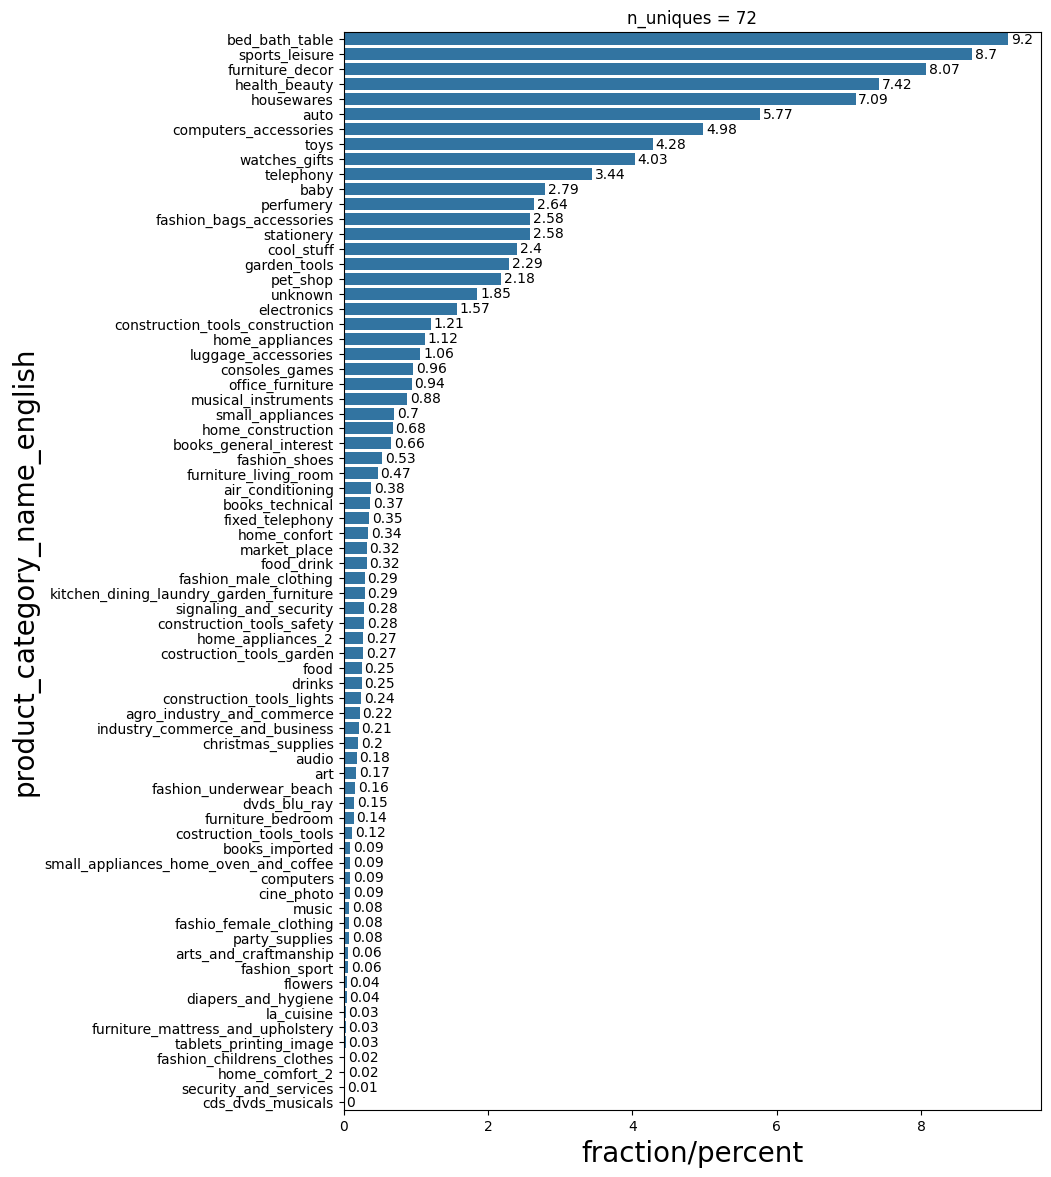

In [146]:
UVA.category(products, ['product_category_name_english'], 9, 14)

### process by customer

In [147]:
#ord_df.head()

In [148]:
#products.head()

In [149]:
#matching_table.head()

In [150]:
custo_product = matching_table[['customer_unique_id', 'product_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')
custo_product.head()

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,home
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty


In [151]:
# check custo_product nans
custo_product.isna().sum()

customer_unique_id          0
product_id                  0
product_global_category    24
dtype: int64

In [152]:
custo_product.loc[custo_product['product_global_category'].isna()]

,customer_unique_id,product_id,product_global_category
55931,ef3210ff1b594a76939d1b3686e7fd02,c7a3f1a7f9eef146cc499368b578b884,NaN
55932,81a79f384f8602573644b70698bab3b1,c7a3f1a7f9eef146cc499368b578b884,NaN
55933,c283a677fa9937143f13fe6f58fd901d,c7a3f1a7f9eef146cc499368b578b884,NaN
57704,949921a7831eb8901f75baf57d1853bf,0105b5323d24fc655f73052694dbbb3a,NaN
57705,11b47516f8f6a42105b9807903ede333,0105b5323d24fc655f73052694dbbb3a,NaN
57706,28d9650a4a5f00fcc716da5ee2460012,0105b5323d24fc655f73052694dbbb3a,NaN
57707,b25c62ba4fc28e41117f8026bf9a31b5,0105b5323d24fc655f73052694dbbb3a,NaN
57708,b70d126df03b594cb148da07860d1534,0105b5323d24fc655f73052694dbbb3a,NaN
75427,24a0683609e642fe0d86e5e2c97712f5,1954739d84629e7323a4295812a3e0ec,NaN
75431,f7f16795a1871264c01bd5464a30b437,a4756663d007b0cd1af865754d08d968,NaN


In [153]:
# fill the 24 lines with NaN global categories : unknown
custo_product['product_global_category'].fillna("unknown", inplace=True)
custo_product['product_global_category'].isnull().value_counts()

False    112372
Name: product_global_category, dtype: int64

In [154]:
#custo_product.groupby(['customer_unique_id', 'product_global_category']).size().reset_index(name="counts")

In [155]:
df_cus_cat = custo_product[['customer_unique_id', 'product_global_category']].value_counts().reset_index(name="counts")
df_cus_cat.head()

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,0f5ac8d5c31de21d2f25e24be15bbffb,furniture,18


In [156]:
custo_product

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,home
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty
...,...,...,...
112367,2077f7ec37df79c62cc24b7b8f30e8c9,31ec3a565e06de4bdf9d2a511b822b4d,construction
112368,78a159045124eb7601951b917a42034f,241a1ffc9cf969b27de6e72301020268,auto
112369,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,1d187e8e7a30417fda31e85679d96f0f,furniture
112370,e55e436481078787e32349cee9febf5e,6e1c2008dea1929b9b6c27fa01381e90,furniture


#### feature variance filtering

##### prepare monetary values per customer on categories

In [157]:
# pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

,customer_unique_id,auto,books_stationery,construction,electronics,fashion,furniture,garden,health_beauty,home,misc,sports_leisure,toys_gifts,unknown
0,0000366f3b9a7992bf8c76cfdf3221e2,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0000f46a3911fa3c0805444483337064,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0004aac84e0df4da2b147fca70cf8255,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,0,0,0,0,0,2,0,0,0,0,0
94717,fffea47cd6d3cc0a88bd621562a9d061,0,0,0,0,0,0,0,1,0,0,0,0,0
94718,ffff371b4d645b6ecea244b27531430a,1,0,0,0,0,0,0,0,0,0,0,0,0
94719,ffff5962728ec6157033ef9805bacc48,0,0,0,0,0,0,0,0,0,0,0,1,0


In [158]:
# change focus : monetary value per sub-category rather than order count per main category :

In [159]:
custo_product_all_cat = matching_table[['customer_unique_id', 'product_id', 'order_id', 'price']]\
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='inner')
custo_product_all_cat.head()

,customer_unique_id,product_id,order_id,price,product_category_name_english
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,e481f51cbdc54678b7cc49136f2d6af7,29.99,housewares
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,128e10d95713541c87cd1a2e48201934,29.99,housewares
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,0e7e841ddf8f8f2de2bad69267ecfbcf,29.99,housewares
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,bfc39df4f36c3693ff3b63fcbea9e90a,29.99,housewares
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,8736140c61ea584cb4250074756d8f3b,75.90,baby


In [160]:
custo_product_all_cat.isna().sum()

customer_unique_id                0
product_id                        0
order_id                          0
price                             0
product_category_name_english    24
dtype: int64

In [161]:
matching_table.duplicated().sum()

0

In [162]:
custo_product_all_cat.duplicated().sum()

10744

In [163]:
custo_product_all_cat[custo_product_all_cat.duplicated()]

,customer_unique_id,product_id,order_id,price,product_category_name_english
10,8cafc4a24a917c4a9084b763a82baf66,b00a32a0b42fd65efb58a5822009f629,e3cc61bbc1cfe072879400a8d82f10a2,79.90,baby
79,958ac7760e5484df1496ba5833ab6117,595fac2a385ac33a80bd5114aec74eb8,d543201a9b42a1402ff97e65b439a48b,116.90,perfumery
90,f5985137de910a1e58ed6bc3214a4100,595fac2a385ac33a80bd5114aec74eb8,f4d33a3db484fba77b5f1f1990fb3445,116.90,perfumery
115,60a1e88691ef46c62b52fb2b994d7675,595fac2a385ac33a80bd5114aec74eb8,78037c5f4d9f1f7bab0207f22c4e92f1,117.90,perfumery
121,7dd163b8e3d4e09daa9e16091dd6dd26,595fac2a385ac33a80bd5114aec74eb8,9883744c6400cfad8a620ddb82b9793c,119.90,perfumery
...,...,...,...,...,...
112346,803c530613f5c4ee03502be0d6894de0,0c40401eba358c9ef2ff2df80b6eab52,c894fad29c885c81201d9bdd80cd68c5,41.33,unknown
112347,803c530613f5c4ee03502be0d6894de0,0c40401eba358c9ef2ff2df80b6eab52,c894fad29c885c81201d9bdd80cd68c5,41.33,unknown
112351,a38640e92b9b5084cad12f3f3b200a83,6292e8c74db1d4defdbd8244c1101bb6,b6b9f5144b004ad3db40567cdce34811,23.90,perfumery
112364,0b39f417a3c099ff0497346258e8d752,710e8b076db06c8e5343a9e23f0e3d83,5bacbd9f42bd029c3a296501224e193e,44.99,sports_leisure


In [164]:
# not dropping duplicates, considering it's possible to buy multiple of the same product_id within the same order
#custo_product_all_cat.drop_duplicates(inplace=True)
print(custo_product_all_cat.duplicated().sum())
print(custo_product_all_cat.shape)

10744
(112372, 5)


In [165]:
# agg per customer_unique_id : total sum/price per category
all_cat_monetary = custo_product_all_cat.groupby(['customer_unique_id', 'product_category_name_english'])['price'].sum().reset_index()


In [166]:
df_cus_all_cat_pivot = all_cat_monetary.pivot_table(index=['customer_unique_id']
                                            ,columns='product_category_name_english'
                                            ,values='price'
                                           )\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
df_cus_all_cat_pivot

,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,books_technical,cds_dvds_musicals,christmas_supplies,cine_photo,computers,computers_accessories,consoles_games,construction_tools_construction,construction_tools_lights,construction_tools_safety,cool_stuff,costruction_tools_garden,costruction_tools_tools,diapers_and_hygiene,drinks,dvds_blu_ray,electronics,fashio_female_clothing,fashion_bags_accessories,fashion_childrens_clothes,fashion_male_clothing,fashion_shoes,fashion_sport,fashion_underwear_beach,fixed_telephony,flowers,food,food_drink,furniture_bedroom,furniture_decor,furniture_living_room,furniture_mattress_and_upholstery,garden_tools,health_beauty,home_appliances,home_appliances_2,home_comfort_2,home_confort,home_construction,housewares,industry_commerce_and_business,kitchen_dining_laundry_garden_furniture,la_cuisine,luggage_accessories,market_place,music,musical_instruments,office_furniture,party_supplies,perfumery,pet_shop,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,unknown,watches_gifts
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,129.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0,0.00,0.0,0.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,0.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1570.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
fffea47cd6d3cc0a88bd621562a9d061,0.0,0.0,0.0,0.0,0.0,0.0,64.89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
ffff371b4d645b6ecea244b27531430a,0.0,0.0,0.0,0.0,0.0,89.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [167]:
print(df_cus_all_cat_pivot.isna().sum().sum())
print(df_cus_all_cat_pivot.duplicated().sum())

0
71265


In [168]:
cols_list = df_cus_all_cat_pivot.columns
len(cols_list)

72

In [169]:
kept_cols = ['auto', 'baby', 'bed_bath_table', 'computers', 'computers_accessories',
       'cool_stuff', 'fixed_telephony', 'furniture_decor', 'garden_tools',
       'health_beauty', 'home_appliances_2', 'housewares',
       'musical_instruments', 'office_furniture', 'small_appliances',
       'sports_leisure', 'telephony', 'toys', 'watches_gifts']
kept_cols

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts']

In [170]:
df_reduced = df_cus_all_cat_pivot[kept_cols]
df_reduced.head()

,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts
customer_unique_id,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,129.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.00,0.0,0.0


In [171]:
pivot_cols = df_cus_all_cat_pivot.columns.tolist()
others_merge_columns = [col for col in pivot_cols if col not in kept_cols]

In [172]:
print(len(kept_cols))
print(len(others_merge_columns))
print(df_cus_all_cat_pivot.shape[1])

19
53
72


In [173]:
merge_others_cat = df_cus_all_cat_pivot[others_merge_columns].sum(axis=1).reset_index().rename(columns={0:"other_categories"})
merge_others_cat

,customer_unique_id,other_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,0.00
4,0004aac84e0df4da2b147fca70cf8255,0.00
...,...,...
94696,fffcf5a5ff07b0908bd4e2dbc735a684,0.00
94697,fffea47cd6d3cc0a88bd621562a9d061,0.00
94698,ffff371b4d645b6ecea244b27531430a,0.00
94699,ffff5962728ec6157033ef9805bacc48,0.00


In [174]:
df_cat_pivot_reduc = df_cus_all_cat_pivot[kept_cols].merge(merge_others_cat, on = 'customer_unique_id', how= 'left')
df_cat_pivot_reduc

,customer_unique_id,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.00,129.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
2,0000f46a3911fa3c0805444483337064,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,0.00
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.00,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1570.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
94697,fffea47cd6d3cc0a88bd621562a9d061,0.0,64.89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
94698,ffff371b4d645b6ecea244b27531430a,89.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
94699,ffff5962728ec6157033ef9805bacc48,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,115.0,0.00


In [175]:
# check variance of merged column :
np.var(df_cat_pivot_reduc['other_categories'])

11146.448393839244

In [176]:
# check individual variance of columns to merge :
np.var(df_cus_all_cat_pivot[others_merge_columns]).sort_values(ascending=False)

agro_industry_and_commerce                 988.292028
construction_tools_construction            986.483068
consoles_games                             955.697617
perfumery                                  922.923762
unknown                                    919.347622
pet_shop                                   724.871759
small_appliances_home_oven_and_coffee      611.575150
electronics                                560.064334
art                                        466.337507
home_appliances                            451.962472
stationery                                 430.688411
fashion_bags_accessories                   407.685554
luggage_accessories                        346.608506
construction_tools_safety                  342.114093
air_conditioning                           306.237442
home_construction                          297.625774
industry_commerce_and_business             249.199897
furniture_living_room                      236.768943
kitchen_dining_laundry_garde

In [177]:
# merge into dataset
df_customers = df_customers.merge(df_cat_pivot_reduc, on='customer_unique_id', how='left')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories
0,7c396fd4830fd04220f754e42b4e5bff,380,2,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,af07308b275d755c9edb36a90c618231,85,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7c142cf63193a1473d2e66489a9ae977,333,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96090,6359f309b166b0196dbf7ad2ac62bb5a,587,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96091,da62f9e57a76d978d02ab5362c509660,253,1,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96092,737520a9aad80b3fbbdad19b66b37b30,416,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96093,5097a5312c8b157bb7be58ae360ef43c,282,1,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [178]:
df_customers.isna().sum()

customer_unique_id          0
recency                     0
frequency                   0
auto                     1394
baby                     1394
bed_bath_table           1394
computers                1394
computers_accessories    1394
cool_stuff               1394
fixed_telephony          1394
furniture_decor          1394
garden_tools             1394
health_beauty            1394
home_appliances_2        1394
housewares               1394
musical_instruments      1394
office_furniture         1394
small_appliances         1394
sports_leisure           1394
telephony                1394
toys                     1394
watches_gifts            1394
other_categories         1394
dtype: int64

In [179]:
df_customers.duplicated().sum()

0

In [180]:
kept_cols_2 = kept_cols
kept_cols_2.append('other_categories')
kept_cols_2

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts',
 'other_categories']

In [181]:
kept_cols_2

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts',
 'other_categories']

In [182]:
#df_customers_2 = df_customers.copy()
#df_customers_2['monetary_2'] = df_customers_2[kept_cols_2].sum(axis=1)
#df_customers_2.drop(columns=kept_cols_2, inplace=True)
#df_customers_2

In [183]:
#df_customers_2[df_customers_2['monetary']!=df_customers_2['monetary_2']]

In [184]:
#df_customers_2[df_customers_2['monetary']!=df_customers_2['monetary_2']]['customer_unique_id'].nunique()

In [185]:
df_customers.dropna(inplace=True)

In [186]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
frequency                0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
dtype: int64

#### Main cat per customer

In [187]:
idx = df_cus_cat.groupby(['customer_unique_id'])['product_global_category','counts'].idxmax()
#max_counts = df_cus_cat[idx]

In [188]:
idx = df_cus_cat.groupby('customer_unique_id')['counts'].idxmax()

In [189]:
cus_cat_max = df_cus_cat[df_cus_cat.index.isin(idx)]
cus_cat_max

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,0f5ac8d5c31de21d2f25e24be15bbffb,furniture,18
...,...,...,...
96832,59b5158dcd4ab8fce908aba30ea36cc9,toys_gifts,1
96833,59b4ec664e6f745f06ebba9d33c475e0,furniture,1
96834,59b46e4ceb1bca705bbae5644d5918db,health_beauty,1
96835,59b265b9cfda8d25bbc84f722b90b139,electronics,1


In [190]:
df_cus_cat['customer_unique_id'].value_counts()

74cb1ad7e6d5674325c1f99b5ea30d82    5
47c1a3033b8b77b3ab6e109eb4d5fdf3    5
4e65032f1f574189fb793bac5a867bbc    4
8c21dd8c37144807c601f99f2a209dfb    4
35ecdf6858edc6427223b64804cf028e    4
                                   ..
e5203612ca86f5cf6e916ed0dacf45b9    1
e5205088eca54b8d927b29076a1ee913    1
e52200bf2286a9a1ab3a37a45a86b85c    1
e5226aca1f153cc7e1de202c2a259035    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: customer_unique_id, Length: 94721, dtype: int64

In [191]:
df_cus_cat.loc[df_cus_cat['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,product_global_category,counts
23,3e43e6105506432c953e165fb2acf44c,furniture,11
57445,3e43e6105506432c953e165fb2acf44c,home,1
57446,3e43e6105506432c953e165fb2acf44c,electronics,1
57447,3e43e6105506432c953e165fb2acf44c,construction,1


In [192]:
cus_cat_max.loc[cus_cat_max['customer_unique_id'] == '8c21dd8c37144807c601f99f2a209dfb']

,customer_unique_id,product_global_category,counts
7789,8c21dd8c37144807c601f99f2a209dfb,fashion,2


In [193]:
cus_cat_max.rename(columns={"product_global_category":"main_category"}, inplace=True)
cus_cat_max

,customer_unique_id,main_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,0f5ac8d5c31de21d2f25e24be15bbffb,furniture,18
...,...,...,...
96832,59b5158dcd4ab8fce908aba30ea36cc9,toys_gifts,1
96833,59b4ec664e6f745f06ebba9d33c475e0,furniture,1
96834,59b46e4ceb1bca705bbae5644d5918db,health_beauty,1
96835,59b265b9cfda8d25bbc84f722b90b139,electronics,1


In [194]:
# merge max_category into
df_customers = df_customers.merge(cus_cat_max[['customer_unique_id', 'main_category']], on='customer_unique_id', how='left')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category
0,7c396fd4830fd04220f754e42b4e5bff,380,2,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home
1,af07308b275d755c9edb36a90c618231,85,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto
3,7c142cf63193a1473d2e66489a9ae977,333,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty
94697,da62f9e57a76d978d02ab5362c509660,253,1,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty
94698,737520a9aad80b3fbbdad19b66b37b30,416,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home
94699,5097a5312c8b157bb7be58ae360ef43c,282,1,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics


In [195]:
#UVA.category(products, ['product_global_category'], 9, 5)

In [196]:
df_cus_cat

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,0f5ac8d5c31de21d2f25e24be15bbffb,furniture,18
...,...,...,...
96832,59b5158dcd4ab8fce908aba30ea36cc9,toys_gifts,1
96833,59b4ec664e6f745f06ebba9d33c475e0,furniture,1
96834,59b46e4ceb1bca705bbae5644d5918db,health_beauty,1
96835,59b265b9cfda8d25bbc84f722b90b139,electronics,1


In [197]:
# pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

,customer_unique_id,auto,books_stationery,construction,electronics,fashion,furniture,garden,health_beauty,home,misc,sports_leisure,toys_gifts,unknown
0,0000366f3b9a7992bf8c76cfdf3221e2,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0000f46a3911fa3c0805444483337064,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0004aac84e0df4da2b147fca70cf8255,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,0,0,0,0,0,2,0,0,0,0,0
94717,fffea47cd6d3cc0a88bd621562a9d061,0,0,0,0,0,0,0,1,0,0,0,0,0
94718,ffff371b4d645b6ecea244b27531430a,1,0,0,0,0,0,0,0,0,0,0,0,0
94719,ffff5962728ec6157033ef9805bacc48,0,0,0,0,0,0,0,0,0,0,0,1,0


## Freight value

In [198]:
df_freight_value = ord_df.groupby('customer_unique_id')['freight_value'].sum().reset_index()
df_freight_value

,customer_unique_id,freight_value
0,0000366f3b9a7992bf8c76cfdf3221e2,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,8.29
2,0000f46a3911fa3c0805444483337064,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,17.63
4,0004aac84e0df4da2b147fca70cf8255,16.89
...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,497.42
95416,fffea47cd6d3cc0a88bd621562a9d061,19.69
95417,ffff371b4d645b6ecea244b27531430a,22.56
95418,ffff5962728ec6157033ef9805bacc48,18.69


In [199]:
df_customers = df_customers.merge(df_freight_value, on='customer_unique_id')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,380,2,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44
1,af07308b275d755c9edb36a90c618231,85,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22
3,7c142cf63193a1473d2e66489a9ae977,333,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,13.08
94697,da62f9e57a76d978d02ab5362c509660,253,1,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,20.10
94698,737520a9aad80b3fbbdad19b66b37b30,416,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,65.02
94699,5097a5312c8b157bb7be58ae360ef43c,282,1,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics,81.18


In [200]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
frequency                0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
dtype: int64

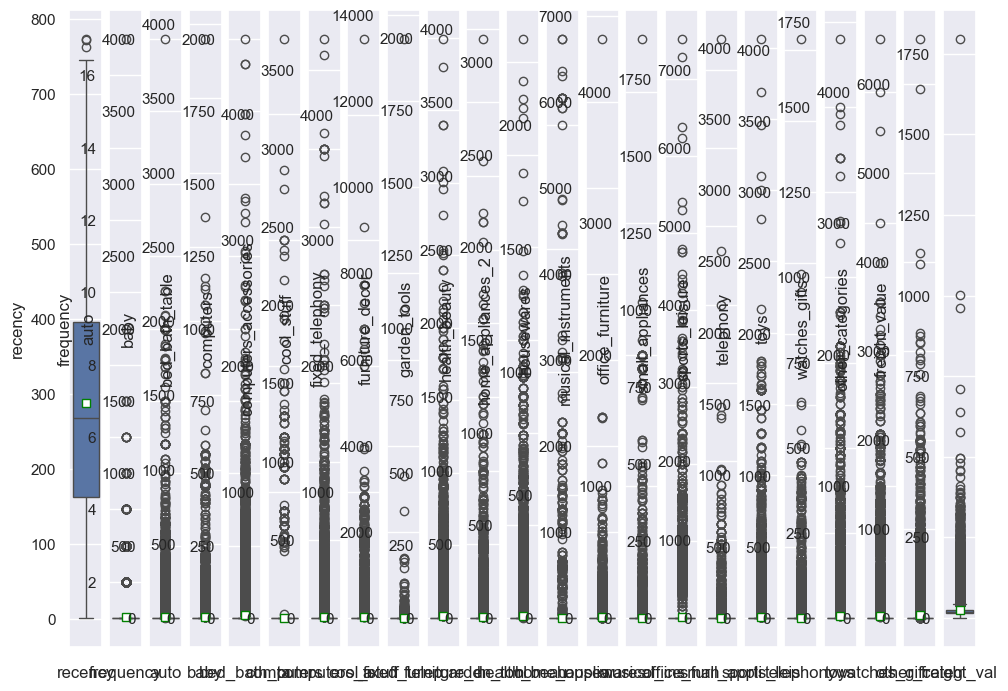

In [201]:
num_cols = df_customers.select_dtypes(include=np.number).columns.to_list()
MVA.boxplot_nums(df_customers, num_cols)

### weight / length / heigh / width

#### New method : bins and count per category

In [202]:
#products[products.product_weight_g.isna()]

In [203]:
#products.drop(products[products.product_weight_g.isna()].index, inplace=True)

In [204]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [205]:
# bin products by weight : light / medium / heavy
# https://www.geeksforgeeks.org/how-to-use-pandas-cut-and-qcut/
products['weight_qcut'] = pd.qcut(products['product_weight_g'], q=3
                                  ,labels = ['light'
                                             ,'medium'
                                             ,'heavy'
                                          ]
                                 )
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,weight_qcut
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0,light
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,medium
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,light
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0,light
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0,medium


In [206]:
# bins value details
pd.qcut(products['product_weight_g'], q=3).value_counts()

(-0.001, 400.0]      11338
(400.0, 1300.0]      10878
(1300.0, 40425.0]    10733
Name: product_weight_g, dtype: int64

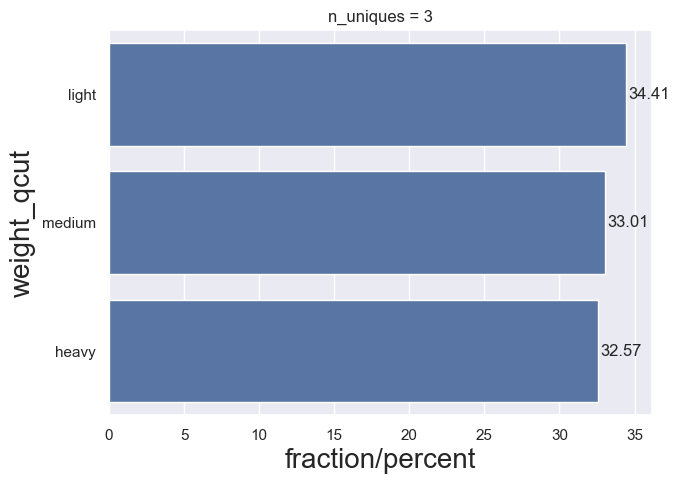

In [207]:
UVA.category(products,['weight_qcut'])

In [208]:
matching_table = matching_table.merge(products[['product_id','weight_qcut']], on='product_id', how='left')

In [209]:
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,weight_qcut
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,medium
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP,light
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP,heavy
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP,heavy
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,1ab38815794efa43d269d62b98dae815,a0b67404d84a70ef420a7f99ad6b190a,delivered,2018-07-01 10:23:10,2018-07-05 16:17:52,2018-07-04 14:34:00,2018-07-09 15:06:57,2018-07-20,2077f7ec37df79c62cc24b7b8f30e8c9,8528,ferraz de vasconcelos,SP,7f9849fcbfdf9fa3070c05b5501bf066,5,NaN,NaN,2018-07-10,2018-07-10 18:32:29,1,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2018-07-10 08:32:33,79.00,14.13,13660,porto ferreira,SP,medium
112368,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04-01,2017-04-01 10:24:03,1,241a1ffc9cf969b27de6e72301020268,8501d82f68d23148b6d78bb7c4a42037,2017-03-16 19:51:36,19.70,10.96,89031,blumenau,SC,light
112369,735dce2d574afe8eb87e80a3d6229c48,d531d01affc2c55769f6b9ed410d8d3c,delivered,2018-07-24 09:46:27,2018-07-24 11:24:27,2018-07-24 15:14:00,2018-08-02 22:47:35,2018-08-16,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,60455,fortaleza,CE,19f21ead7ffe5b1b5147a7877c22bae5,5,NaN,

In [210]:
weight_cat_ord_count = matching_table.groupby(['customer_unique_id', 'weight_qcut'])['order_id'].nunique().reset_index()
weight_cat_ord_count.rename(columns={'order_id':"count_orders"}, inplace=True)
weight_cat_ord_count

,customer_unique_id,weight_qcut,count_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,light,0
1,0000366f3b9a7992bf8c76cfdf3221e2,medium,0
2,0000366f3b9a7992bf8c76cfdf3221e2,heavy,1
3,0000b849f77a49e4a4ce2b2a4ca5be3f,light,1
4,0000b849f77a49e4a4ce2b2a4ca5be3f,medium,0
...,...,...,...
284158,ffff5962728ec6157033ef9805bacc48,medium,1
284159,ffff5962728ec6157033ef9805bacc48,heavy,0
284160,ffffd2657e2aad2907e67c3e9daecbeb,light,1
284161,ffffd2657e2aad2907e67c3e9daecbeb,medium,0


In [211]:
### pivot and merge all qcut orders_count details
weight_cat_pivot = weight_cat_ord_count.pivot_table(index=['customer_unique_id']
                                            ,columns='weight_qcut'
                                            ,values='count_orders'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)

weight_cat_pivot.rename(columns={'light':'frequency_light', 'medium':'frequency_medium', 'heavy':'frequency_heavy'}, inplace=True)
weight_cat_pivot

,customer_unique_id,frequency_light,frequency_medium,frequency_heavy
0,0000366f3b9a7992bf8c76cfdf3221e2,0,0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,0,0
2,0000f46a3911fa3c0805444483337064,0,0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,0,0
4,0004aac84e0df4da2b147fca70cf8255,0,0,1
...,...,...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,1
94717,fffea47cd6d3cc0a88bd621562a9d061,0,0,1
94718,ffff371b4d645b6ecea244b27531430a,0,1,0
94719,ffff5962728ec6157033ef9805bacc48,0,1,0


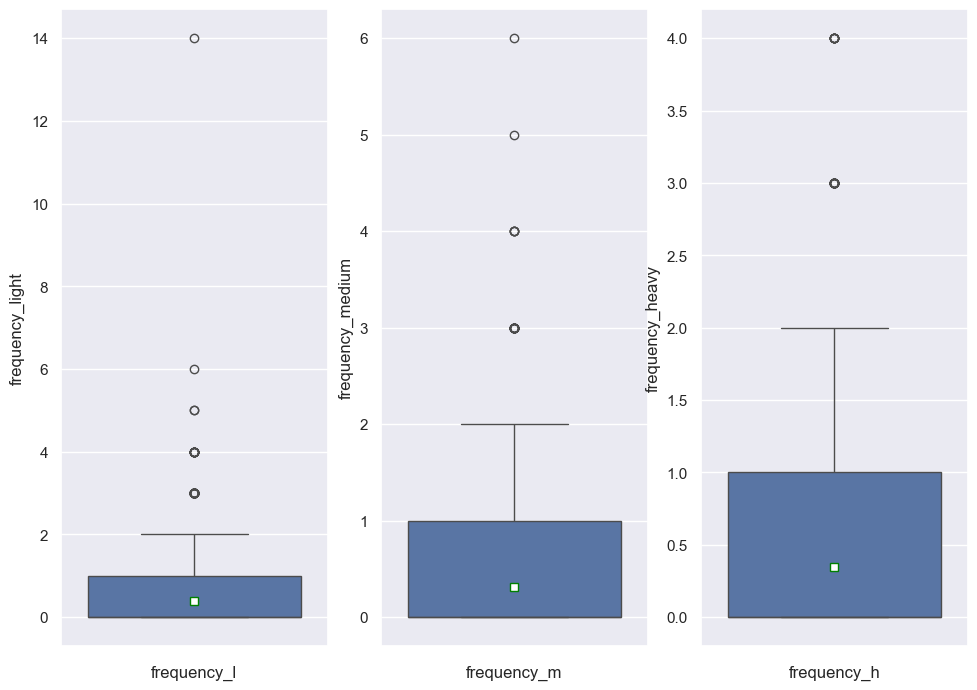

In [212]:
num_cols_cat_pivot = weight_cat_pivot.select_dtypes(include=np.number).columns.to_list()
MVA.boxplot_nums(weight_cat_pivot, num_cols_cat_pivot)

In [213]:
weight_cat_pivot[num_cols_cat_pivot].sum()

frequency_light     36129
frequency_medium    29719
frequency_heavy     33035
dtype: int64

In [214]:
weight_cat_pivot.describe()

,frequency_light,frequency_medium,frequency_heavy
count,94721.000000,94721.000000,94721.000000
mean,0.381425,0.313753,0.348761
std,0.506758,0.476458,0.490876
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,14.000000,6.000000,4.000000


In [215]:
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,380,2,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44
1,af07308b275d755c9edb36a90c618231,85,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22
3,7c142cf63193a1473d2e66489a9ae977,333,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,13.08
94697,da62f9e57a76d978d02ab5362c509660,253,1,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,20.10
94698,737520a9aad80b3fbbdad19b66b37b30,416,1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,65.02
94699,5097a5312c8b157bb7be58ae360ef43c,282,1,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics,81.18


In [216]:
df_customers = df_customers.merge(weight_cat_pivot, on='customer_unique_id', how='left')
df_customers.drop(columns=['frequency'], inplace=True) # now redundant column
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0


## Sellers

In [217]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [218]:
sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [219]:
sellers.duplicated().sum()

0

In [220]:
sellers['seller_id'].duplicated().sum()

0

In [221]:
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,weight_qcut
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,medium
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP,light
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP,heavy
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP,heavy
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,1ab38815794efa43d269d62b98dae815,a0b67404d84a70ef420a7f99ad6b190a,delivered,2018-07-01 10:23:10,2018-07-05 16:17:52,2018-07-04 14:34:00,2018-07-09 15:06:57,2018-07-20,2077f7ec37df79c62cc24b7b8f30e8c9,8528,ferraz de vasconcelos,SP,7f9849fcbfdf9fa3070c05b5501bf066,5,NaN,NaN,2018-07-10,2018-07-10 18:32:29,1,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2018-07-10 08:32:33,79.00,14.13,13660,porto ferreira,SP,medium
112368,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04-01,2017-04-01 10:24:03,1,241a1ffc9cf969b27de6e72301020268,8501d82f68d23148b6d78bb7c4a42037,2017-03-16 19:51:36,19.70,10.96,89031,blumenau,SC,light
112369,735dce2d574afe8eb87e80a3d6229c48,d531d01affc2c55769f6b9ed410d8d3c,delivered,2018-07-24 09:46:27,2018-07-24 11:24:27,2018-07-24 15:14:00,2018-08-02 22:47:35,2018-08-16,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,60455,fortaleza,CE,19f21ead7ffe5b1b5147a7877c22bae5,5,NaN,

In [222]:
matching_table.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [223]:
df_sellers_count = matching_table.groupby('customer_unique_id')['seller_id'].nunique().reset_index()
df_sellers_count.columns = ['customer_unique_id','sellers_count']

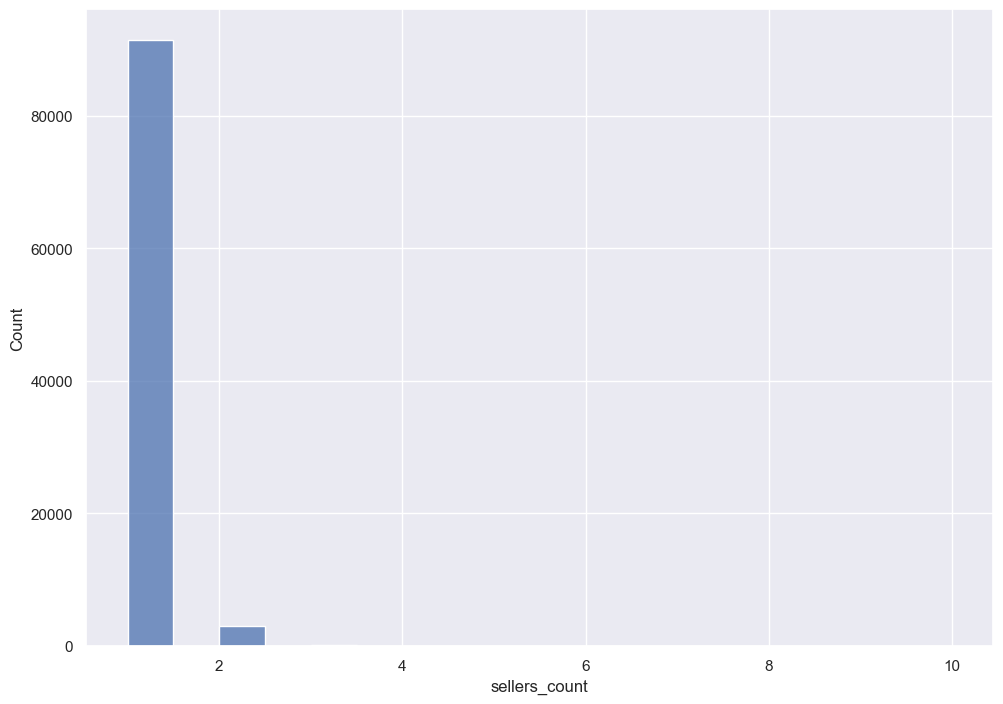

In [224]:
ax = sns.histplot(df_sellers_count['sellers_count'])

In [225]:
# qcut / cut ?

In [226]:
df_customers = df_customers.merge(df_sellers_count, on='customer_unique_id')
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,13.08,0,1,0,1
94697,da62f9e57a76d978d02ab5362c509660,253,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,20.10,0,0,1,1
94698,737520a9aad80b3fbbdad19b66b37b30,416,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,65.02,0,0,1,1
94699,5097a5312c8b157bb7be58ae360ef43c,282,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics,81.18,0,0,1,1


In [227]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
dtype: int64

## Most frequently bought categories

### main categories

In [228]:
## redundant ?

## Reviews info

### percent review score shared

In [229]:
matching_table.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [230]:
ord_df.head()

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13


In [231]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53


In [232]:
# check reviews

In [233]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [234]:
score_list = reviews['review_score'].unique().tolist()
score_list.sort()
score_list

[1, 2, 3, 4, 5]

In [235]:
reviews['review_score'].dtype

dtype('int64')

<AxesSubplot:xlabel='review_score', ylabel='Count'>

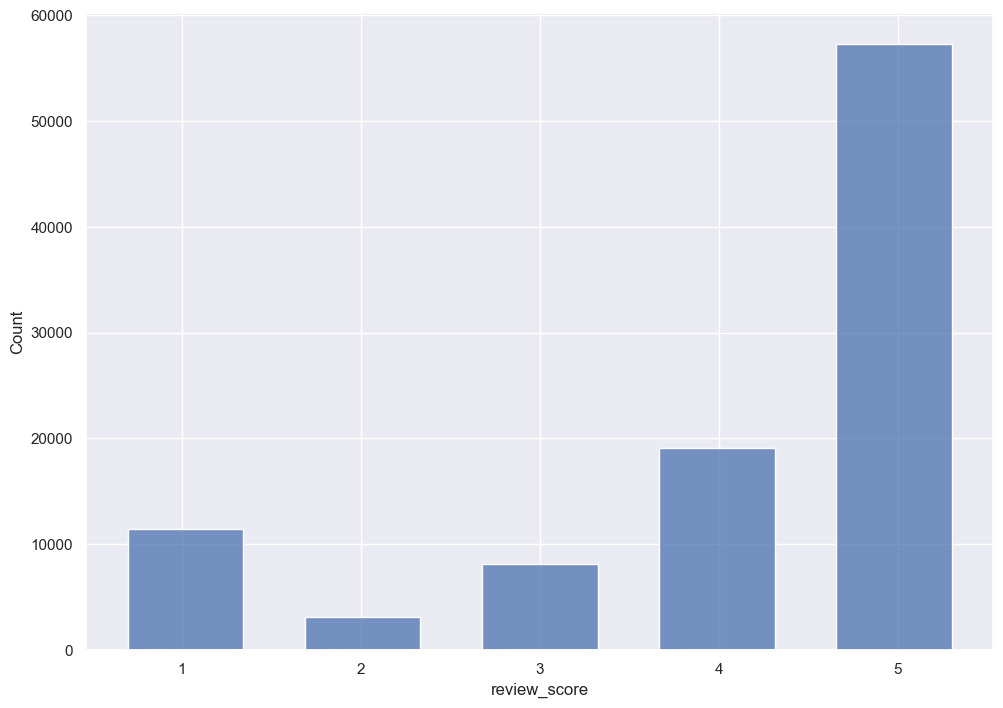

In [236]:
sns.histplot(reviews, x='review_score', shrink=15)

In [237]:
# join/merge tables
custo_reviews = matching_table[['customer_unique_id', 'order_id', 'review_id']]\
            .merge(reviews[['review_id', 'review_score', 'review_comment_message']], on = 'review_id', how='inner')
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b8238c6515192f8129081e17dc57d169,5,"custo beneficio, simples de usar e rápido"
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,36f6f70dc5e67e8e43b109cae0e92d40,4,É garantido e de confiança .


In [238]:
custo_reviews.shape

(114259, 5)

In [239]:
mean_review_score = custo_reviews.groupby(['customer_unique_id'])['review_score'].mean().reset_index()
mean_review_score.rename(columns={"review_score":"mean_review_score"}, inplace=True)
mean_review_score

,customer_unique_id,mean_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4.0
2,0000f46a3911fa3c0805444483337064,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,4.0
4,0004aac84e0df4da2b147fca70cf8255,5.0
...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,5.0
94717,fffea47cd6d3cc0a88bd621562a9d061,4.0
94718,ffff371b4d645b6ecea244b27531430a,5.0
94719,ffff5962728ec6157033ef9805bacc48,5.0


In [240]:
# check result with customer having multiple orders/reviews => float ?
mean_review_score.loc[mean_review_score['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,mean_review_score
23137,3e43e6105506432c953e165fb2acf44c,2.705882


In [241]:
mean_review_score['mean_review_score'].isna().sum()

0

In [242]:
# merge mean_review_score into
df_customers = df_customers.merge(mean_review_score[['customer_unique_id', 'mean_review_score']], on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4.5
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5.0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,5.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5.0


In [243]:
# check nans
df_customers.loc[df_customers['mean_review_score'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score


In [244]:
# other infos are interesting, inputing mean review score by category to complete

# matching each order main category and review score
product_review = matching_table[['customer_unique_id', 'product_id', 'review_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
    .merge(reviews[['review_id', 'review_score']])
product_review

,customer_unique_id,product_id,review_id,product_global_category,review_score
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,a54f0611adc9ed256b57ede6b6eb5114,home,4
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,b46f1e34512b0f4c74a72398b03ca788,home,4
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,dc90f19c2806f1abba9e72ad3c350073,home,5
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,1bafb430e498b939f258b9c9dbdff9b1,home,3
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,b8238c6515192f8129081e17dc57d169,health_beauty,5
...,...,...,...,...,...
114254,2077f7ec37df79c62cc24b7b8f30e8c9,31ec3a565e06de4bdf9d2a511b822b4d,7f9849fcbfdf9fa3070c05b5501bf066,construction,5
114255,78a159045124eb7601951b917a42034f,241a1ffc9cf969b27de6e72301020268,c950324a42c5796d06f569f77d8b2e88,auto,1
114256,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,1d187e8e7a30417fda31e85679d96f0f,19f21ead7ffe5b1b5147a7877c22bae5,furniture,5
114257,e55e436481078787e32349cee9febf5e,6e1c2008dea1929b9b6c27fa01381e90,ec2817e750153dfdd61894780dfc5d9e,furniture,4


In [245]:
product_review['product_global_category'].isna().sum()

24

In [246]:
product_review['product_global_category'].fillna("unknown", inplace=True)

In [247]:
group_cat = product_review.groupby(by='product_global_category')

In [248]:
mean_review_category = product_review.groupby(by='product_global_category')['review_score'].mean()
mean_review_category

product_global_category
auto                4.064448
books_stationery    4.248680
construction        4.019728
electronics         3.956991
fashion             4.109934
furniture           3.860241
garden              4.040000
health_beauty       4.119538
home                4.055649
misc                4.175018
sports_leisure      4.090549
toys_gifts          4.093055
unknown             3.836275
Name: review_score, dtype: float64

In [249]:
# inputing to df_customers with missing review score : the overall mean review score by category
df_customers['mean_review_score'] = group_cat['review_score'].transform(lambda x: x.fillna(x.mean()))

In [250]:
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,13.08,0,1,0,1,5
94697,da62f9e57a76d978d02ab5362c509660,253,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,20.10,0,0,1,1,4
94698,737520a9aad80b3fbbdad19b66b37b30,416,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,65.02,0,0,1,1,1
94699,5097a5312c8b157bb7be58ae360ef43c,282,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics,81.18,0,0,1,1,5


In [251]:
# check nans
df_customers['mean_review_score'].isna().sum()

0

<AxesSubplot:xlabel='mean_review_score', ylabel='Count'>

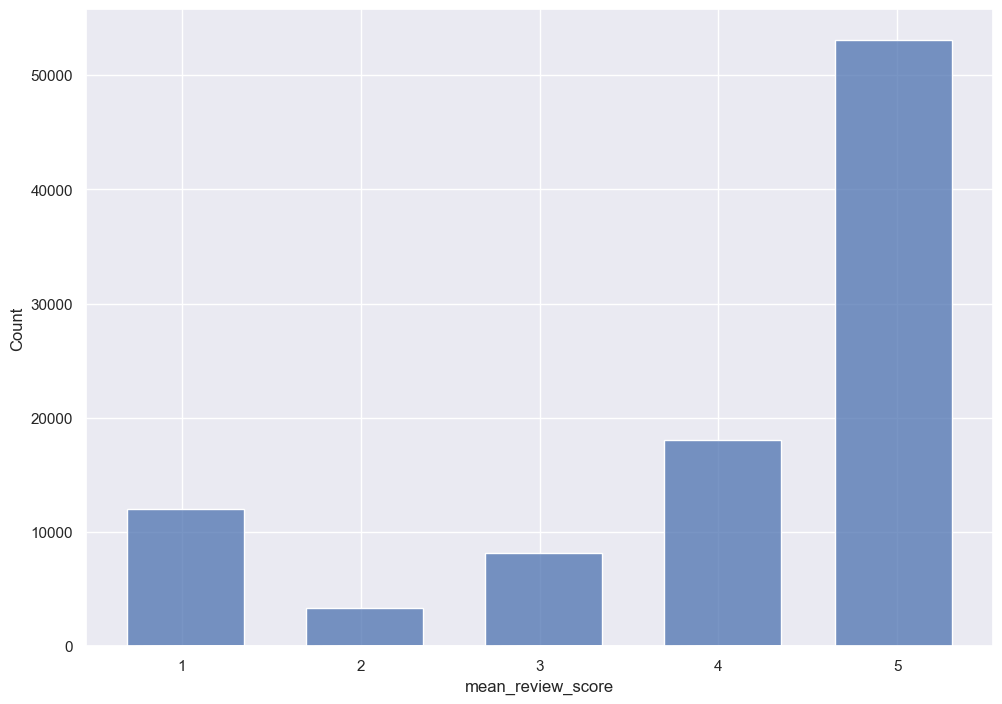

In [252]:
sns.histplot(df_customers, x='mean_review_score', shrink=15)

### percent written review made

In [253]:
custo_reviews['has_comment_message'] = custo_reviews['review_comment_message']
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message,has_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.","Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b8238c6515192f8129081e17dc57d169,5,"custo beneficio, simples de usar e rápido","custo beneficio, simples de usar e rápido"
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,36f6f70dc5e67e8e43b109cae0e92d40,4,É garantido e de confiança .,É garantido e de confiança .


In [254]:
# count percent of na message per customer_unique_id
ratio_text_review = custo_reviews.groupby('customer_unique_id')['review_comment_message']\
                .apply(lambda x: x.notnull().sum()/len(x)*100).reset_index()

ratio_text_review.head()

,customer_unique_id,review_comment_message
0,0000366f3b9a7992bf8c76cfdf3221e2,100.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0
2,0000f46a3911fa3c0805444483337064,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,100.0
4,0004aac84e0df4da2b147fca70cf8255,0.0


In [255]:
ratio_text_review.shape

(94721, 2)

In [256]:
custo_reviews['customer_unique_id'].shape

(114259,)

In [257]:
df_customers = df_customers.merge(ratio_text_review, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0


In [258]:
df_customers.shape

(94701, 30)

In [259]:
# check and handle NaN
df_customers.isna().sum()

customer_unique_id        0
recency                   0
auto                      0
baby                      0
bed_bath_table            0
computers                 0
computers_accessories     0
cool_stuff                0
fixed_telephony           0
furniture_decor           0
garden_tools              0
health_beauty             0
home_appliances_2         0
housewares                0
musical_instruments       0
office_furniture          0
small_appliances          0
sports_leisure            0
telephony                 0
toys                      0
watches_gifts             0
other_categories          0
main_category             0
freight_value             0
frequency_light           0
frequency_medium          0
frequency_heavy           0
sellers_count             0
mean_review_score         0
review_comment_message    0
dtype: int64

In [260]:
df_customers[df_customers['review_comment_message'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,review_comment_message


In [261]:
# other infos for the concerned rows is valuable, 
# NaN here means that the concerned customer_unique_id weren't present in the reviews dataframe
# => insert value 0


In [262]:
df_customers['review_comment_message'].fillna(0, inplace=True)
df_customers.rename(columns={"review_comment_message":"ratio_comment_message"}, inplace=True)
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94696,6359f309b166b0196dbf7ad2ac62bb5a,587,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,13.08,0,1,0,1,5,0.0
94697,da62f9e57a76d978d02ab5362c509660,253,0.0,174.90,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,20.10,0,0,1,1,4,100.0
94698,737520a9aad80b3fbbdad19b66b37b30,416,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,205.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,65.02,0,0,1,1,1,100.0
94699,5097a5312c8b157bb7be58ae360ef43c,282,0.0,0.00,0.0,0.0,359.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,electronics,81.18,0,0,1,1,5,100.0


In [263]:
df_customers[df_customers['customer_unique_id'] == '528b011eb7fab3d59c336cc7248eed3a']

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message


In [264]:
df_customers.shape

(94701, 30)

In [265]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64

In [266]:
df_customers['ratio_comment_message'].value_counts(normalize=True).sort_index(ascending=False)

100.000000    0.407884
90.000000     0.000011
88.888889     0.000032
85.714286     0.000042
83.333333     0.000021
80.000000     0.000306
77.777778     0.000011
75.000000     0.000169
73.333333     0.000011
72.727273     0.000011
71.428571     0.000021
69.230769     0.000011
66.666667     0.000760
62.500000     0.000011
60.000000     0.000074
57.142857     0.000011
50.000000     0.004615
46.153846     0.000011
45.454545     0.000011
44.444444     0.000011
40.000000     0.000021
33.333333     0.000517
28.571429     0.000011
27.272727     0.000011
25.000000     0.000190
23.076923     0.000011
20.000000     0.000222
18.181818     0.000011
16.666667     0.000063
14.285714     0.000032
12.500000     0.000011
0.000000      0.584872
Name: ratio_comment_message, dtype: float64

<AxesSubplot:xlabel='ratio_comment_message', ylabel='Count'>

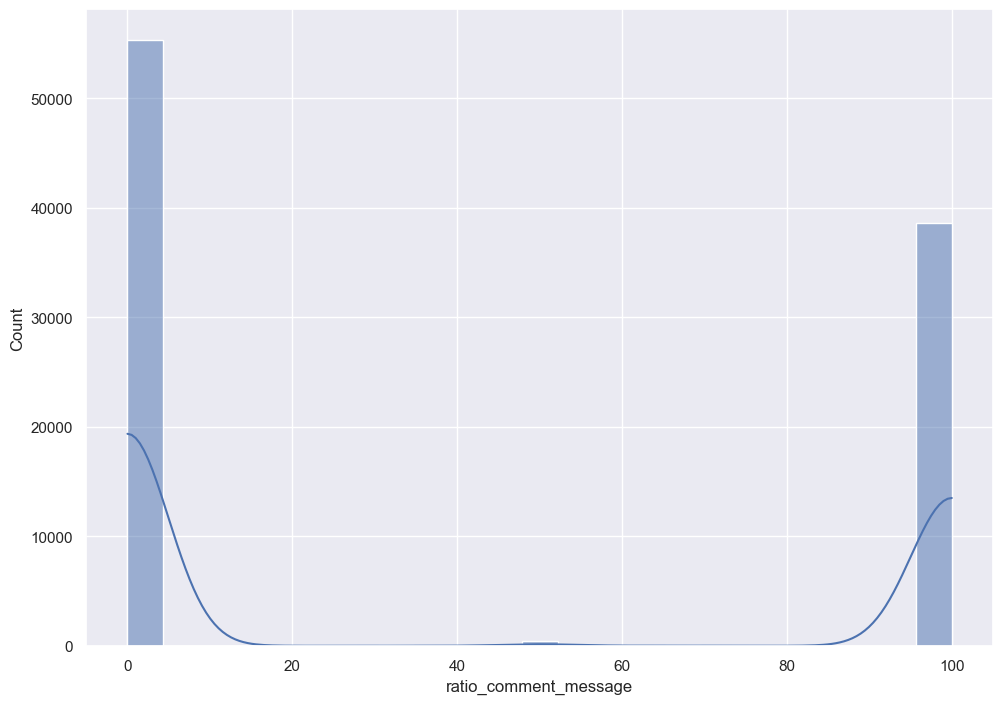

In [267]:
sns.histplot(df_customers, x='ratio_comment_message', kde=True)

## Payment methods

In [268]:
payments = data['order_payments']

In [269]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [270]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [271]:
matching_table.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [272]:
payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='inner')

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,708ab75d2a007f0564aedd11139c7708
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,a8b9d3a27068454b1c98cc67d4e31e6f
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,6f70c0b2f7552832ba46eb57b1c5651e
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,87695ed086ebd36f20404c82d20fca87
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,87695ed086ebd36f20404c82d20fca87
...,...,...,...,...,...,...
117324,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,b6027ac07fb76ebca8c97b1887865aee
117325,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,53b30ca78efb2b7efcd3f9e461587eb2
117326,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,d3c7da954a324253814096bcaf240e4e
117327,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,b84dc68f02f122a88d7e7bbd37b06204


In [273]:
payments_custo = payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='left')
payments_custo

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,708ab75d2a007f0564aedd11139c7708
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,a8b9d3a27068454b1c98cc67d4e31e6f
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,6f70c0b2f7552832ba46eb57b1c5651e
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,87695ed086ebd36f20404c82d20fca87
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,87695ed086ebd36f20404c82d20fca87
...,...,...,...,...,...,...
118935,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,b6027ac07fb76ebca8c97b1887865aee
118936,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,53b30ca78efb2b7efcd3f9e461587eb2
118937,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,d3c7da954a324253814096bcaf240e4e
118938,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,b84dc68f02f122a88d7e7bbd37b06204


In [274]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [275]:
payments_custo.describe()

,payment_sequential,payment_installments,payment_value
count,118940.000000,118940.000000,118940.000000
mean,1.094863,2.939507,172.307369
std,0.730726,2.776571,266.581298
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,60.750000
50%,1.000000,2.000000,108.000000
75%,1.000000,4.000000,189.060000
max,29.000000,24.000000,13664.080000


In [276]:
#payments = matching_table[['customer_unique_id', 'order_id', 'product_id', 'review_id']]\
#    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
#    .merge(reviews[['review_id', 'review_score']])
#payments

In [277]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


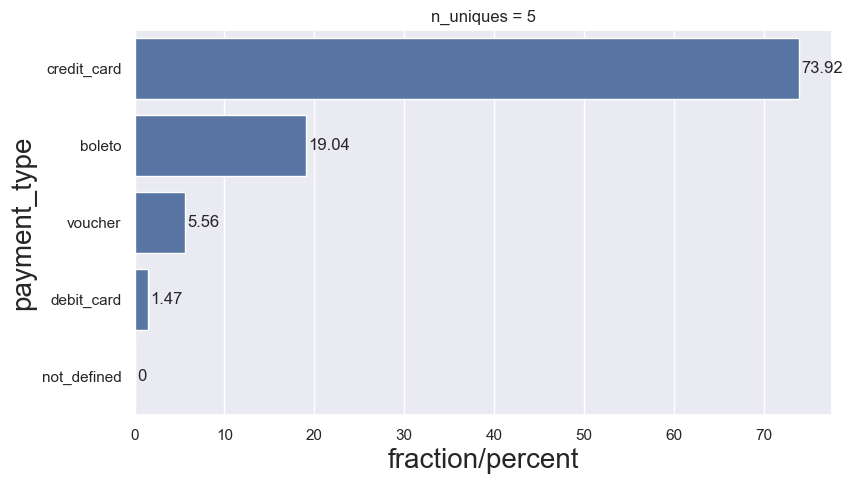

In [278]:
UVA.category(payments, ['payment_type'], 9, 5)

In [279]:
payments['payment_type'].isin(['credit_card']).sum()

76795

In [280]:
# count percent of na message per customer_unique_id
ratio_credit_card = payments_custo.groupby('customer_unique_id')['payment_type']\
                .apply(lambda x: x.isin(['credit_card']).sum()/len(x)*100).reset_index()
ratio_credit_card.rename({'payment_type':'ratio_credit_card'}, axis='columns', inplace=True)

ratio_credit_card.head()

,customer_unique_id,ratio_credit_card
0,0000366f3b9a7992bf8c76cfdf3221e2,100.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,100.0
2,0000f46a3911fa3c0805444483337064,100.0
3,0000f6ccb0745a6a4b88665a16c9f078,100.0
4,0004aac84e0df4da2b147fca70cf8255,100.0


In [281]:
ratio_credit_card['ratio_credit_card'].value_counts(normalize=True).sort_index(ascending=False)

100.000000    0.745925
83.333333     0.000021
80.000000     0.000063
77.777778     0.000011
75.000000     0.000074
66.666667     0.000802
63.636364     0.000011
60.000000     0.000095
57.142857     0.000021
55.555556     0.000011
50.000000     0.020344
42.857143     0.000032
40.000000     0.000063
33.333333     0.002323
30.000000     0.000011
25.000000     0.000697
20.000000     0.000370
16.666667     0.000222
14.285714     0.000158
12.500000     0.000032
11.111111     0.000084
10.000000     0.000021
9.090909      0.000042
8.571429      0.000011
8.333333      0.000032
7.692308      0.000021
7.142857      0.000011
6.666667      0.000011
5.263158      0.000021
4.545455      0.000011
3.846154      0.000011
0.000000      0.228442
Name: ratio_credit_card, dtype: float64

<AxesSubplot:xlabel='ratio_credit_card', ylabel='Count'>

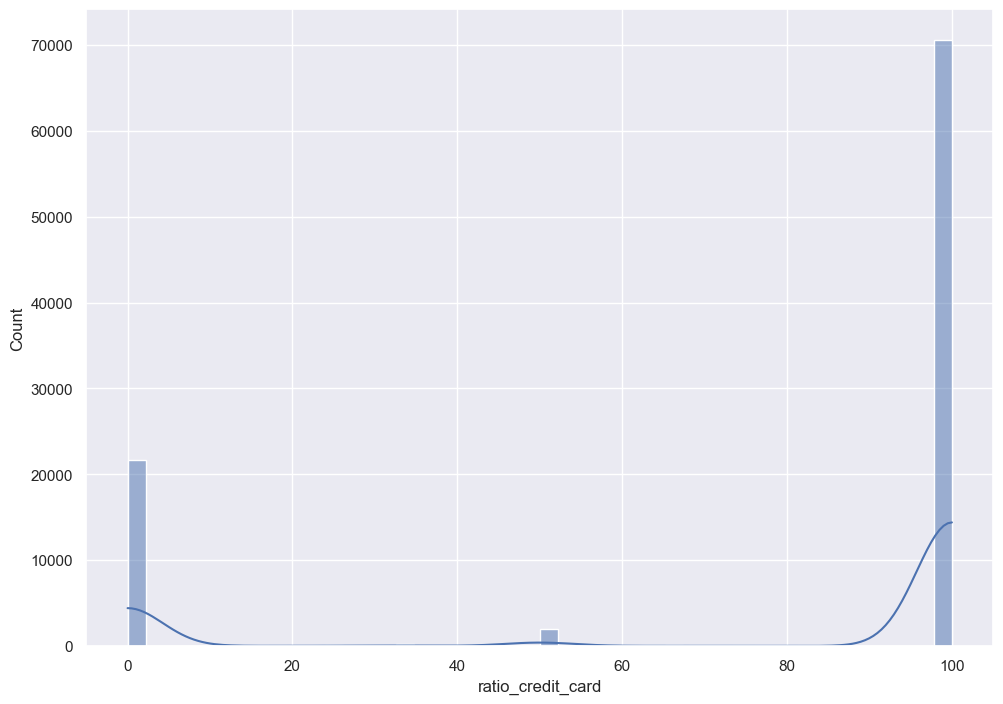

In [282]:
sns.histplot(ratio_credit_card, x='ratio_credit_card', kde=True)

In [283]:
# correlation with mean_pay_installments : removed

#df_customers = df_customers.merge(ratio_credit_card, on='customer_unique_id', how='left')
#df_customers.head()

In [284]:
#check + handling nulls
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64

In [285]:
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0


In [286]:
#df_customers[df_customers['ratio_credit_card'].isna()]

In [287]:
### only 1 => remove

#df_customers.drop(df_customers[df_customers['ratio_credit_card'].isna()].index, inplace=True)

In [288]:
#df_customers['ratio_credit_card'].fillna(100, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(94701, 30)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64


### median payment installments per user :

<AxesSubplot:xlabel='payment_installments', ylabel='Count'>

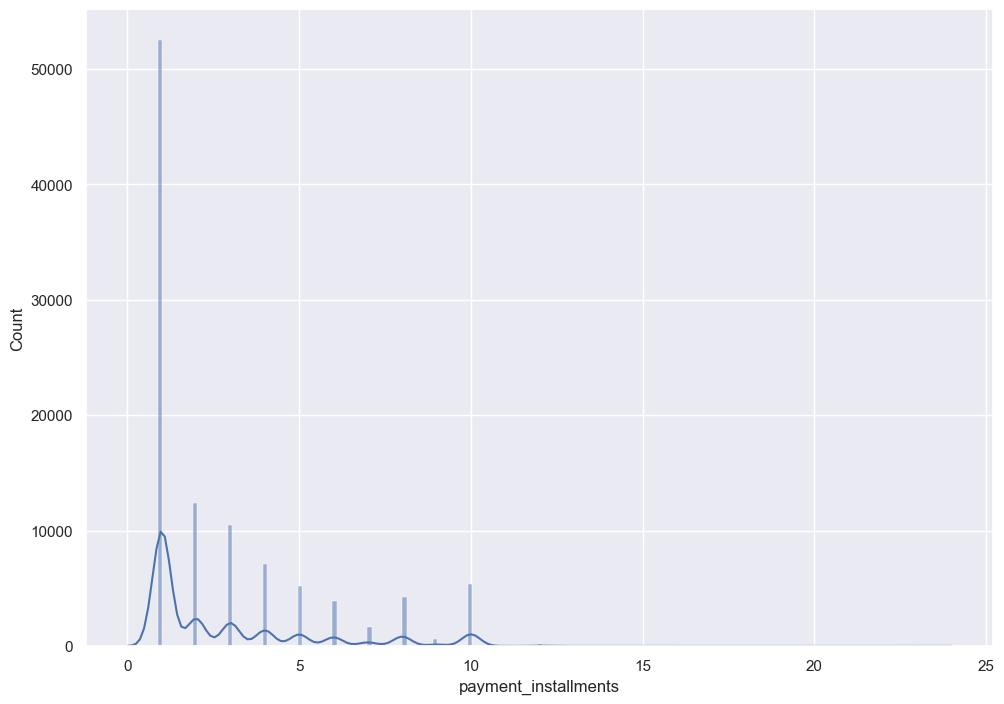

In [289]:
sns.histplot(payments, x='payment_installments', kde=True)

In [290]:
med_pay_install = payments_custo.groupby('customer_unique_id')['payment_installments']\
                .mean().reset_index()
med_pay_install.rename({'payment_installments':'mean_pay_installments'}, axis='columns', inplace=True)

print(med_pay_install.shape)
med_pay_install.head()

(94720, 2)


,customer_unique_id,mean_pay_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.0
2,0000f46a3911fa3c0805444483337064,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,4.0
4,0004aac84e0df4da2b147fca70cf8255,6.0


In [291]:
payments_custo.loc[payments_custo['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
50552,725cf8e9c24e679a8a5a32cb92c9ce1e,1,credit_card,10,2067.42,fffcf5a5ff07b0908bd4e2dbc735a684
50553,725cf8e9c24e679a8a5a32cb92c9ce1e,1,credit_card,10,2067.42,fffcf5a5ff07b0908bd4e2dbc735a684


In [292]:
med_pay_install.loc[med_pay_install['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

,customer_unique_id,mean_pay_installments
94715,fffcf5a5ff07b0908bd4e2dbc735a684,10.0


In [293]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_install, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0,1.0
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0,1.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0,3.0
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0,1.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0,1.0


In [294]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    1
dtype: int64

In [295]:
#handle missing data
df_customers[df_customers['mean_pay_installments'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments
29933,830d5b7aaa3b6f1e9ad63703bec97d23,762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,134.97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,8.49,0,1,0,1,5,100.0,NaN


In [296]:
#df_customers['mean_pay_installments'].fillna(1, inplace=True)
df_customers.drop(df_customers[df_customers['mean_pay_installments'].isna()].index, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(94700, 31)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
dtype: int64


### payment sequential

In [297]:
payments.payment_sequential.value_counts()

1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
18        6
19        6
16        6
17        6
21        4
20        4
22        3
26        2
24        2
23        2
25        2
29        1
28        1
27        1
Name: payment_sequential, dtype: int64

<AxesSubplot:xlabel='payment_sequential', ylabel='Count'>

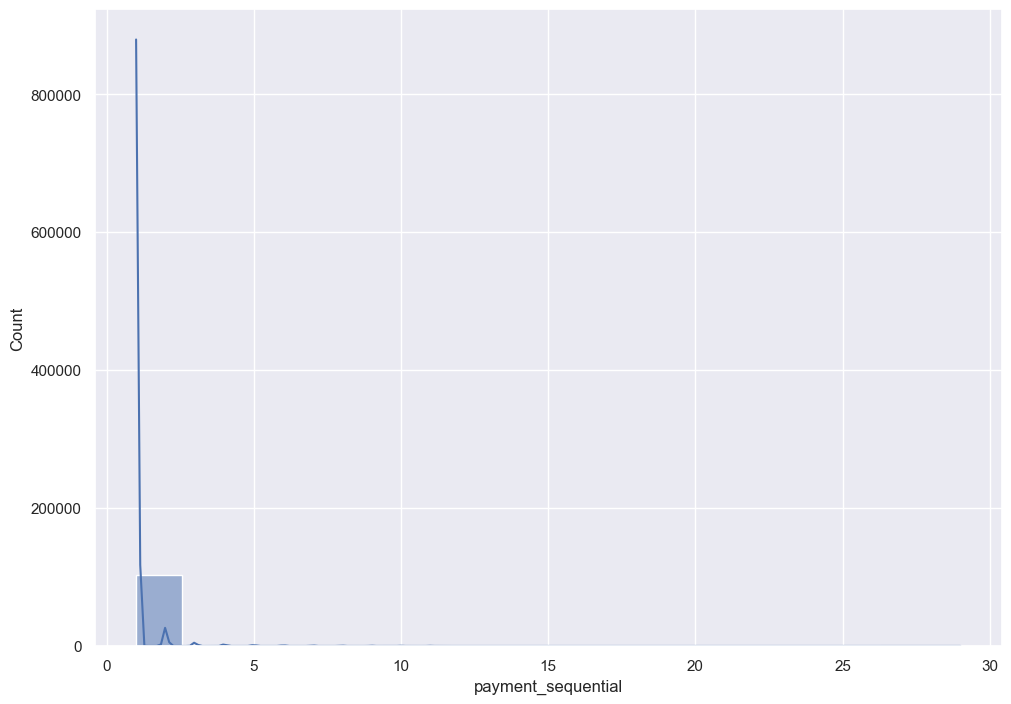

In [298]:
sns.histplot(payments, x='payment_sequential', kde=True)

In [299]:
med_pay_seq = payments_custo.groupby('customer_unique_id')['payment_sequential']\
                .mean().reset_index()
med_pay_seq.rename({'payment_sequential':'mean_pay_sequential'}, axis='columns', inplace=True)

print(med_pay_seq.shape)
med_pay_seq.head()

(94720, 2)


,customer_unique_id,mean_pay_sequential
0,0000366f3b9a7992bf8c76cfdf3221e2,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.0
2,0000f46a3911fa3c0805444483337064,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,1.0
4,0004aac84e0df4da2b147fca70cf8255,1.0


<AxesSubplot:xlabel='mean_pay_sequential', ylabel='Count'>

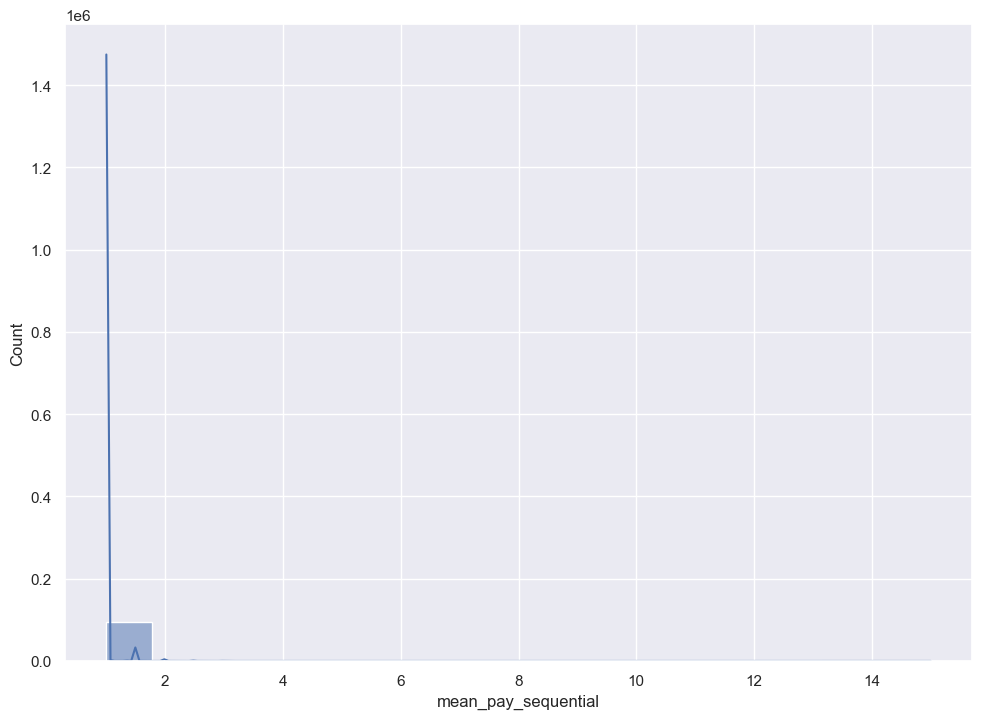

In [300]:
sns.histplot(med_pay_seq, x='mean_pay_sequential', kde=True)

In [301]:
med_pay_seq.sort_values(by='mean_pay_sequential', ascending=False)

,customer_unique_id,mean_pay_sequential
51436,8af7ac63b2efbcbd88e5b11505e8098a,15.00
32131,569aa12b73b5f7edeaa6f2a01603e381,13.50
13826,2524dcec233c3766f2c2b22f69fd65f4,11.50
57213,9a736b248f67d166d2fbb006bcb877c3,10.28
13743,24f12460aad399ba18f4ed2c2fbab65d,10.00
...,...,...
32017,564df947eb9192d7e1613b1b957cb192,1.00
32016,564cb124d13d16afc61936ea12a17c33,1.00
32015,564c03a40766b9b404572658fb74524d,1.00
32014,564bc02acd888f7617b0d7c737d35aee,1.00


In [302]:
payments_custo.loc[payments_custo['customer_unique_id'] == '8af7ac63b2efbcbd88e5b11505e8098a']

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
5577,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02,8af7ac63b2efbcbd88e5b11505e8098a
11395,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16,8af7ac63b2efbcbd88e5b11505e8098a
16335,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71,8af7ac63b2efbcbd88e5b11505e8098a
19725,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08,8af7ac63b2efbcbd88e5b11505e8098a
22380,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86,8af7ac63b2efbcbd88e5b11505e8098a
26387,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51,8af7ac63b2efbcbd88e5b11505e8098a
28457,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68,8af7ac63b2efbcbd88e5b11505e8098a
32456,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66,8af7ac63b2efbcbd88e5b11505e8098a
33958,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02,8af7ac63b2efbcbd88e5b11505e8098a
37254,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03,8af7ac63b2efbcbd88e5b11505e8098a


In [303]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_seq, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
0,7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0,1.0,1.75
1,af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0,1.0,1.00
2,3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0,3.0,1.00
3,7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0,1.0,1.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0,1.0,1.00


In [304]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
mean_pay_sequential      0
dtype: int64

In [305]:
#handle missing data
#df_customers[df_customers['mean_pay_sequential'].isna()]

In [306]:
#df_customers['mean_pay_sequential'].fillna(1, inplace=True)
df_customers.drop(df_customers[df_customers['mean_pay_sequential'].isna()].index, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(94700, 32)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
mean_pay_sequential      0
dtype: int64


In [330]:
df_customers = df_customers.set_index('customer_unique_id')

In [331]:
df_customers.head()

,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0,1.0,1.75
af07308b275d755c9edb36a90c618231,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,health_beauty,22.76,1,0,0,1,4,100.0,1.0,1.00
3a653a41f6f9fc3d2a113cf8398680e8,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,19.22,0,1,0,1,5,0.0,3.0,1.00
7c142cf63193a1473d2e66489a9ae977,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,misc,27.20,0,1,0,1,3,100.0,1.0,1.00
72632f0f9dd73dfee390c9b22eb56dd6,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,books_stationery,8.72,1,0,0,1,5,0.0,1.0,1.00


# Export Dataframe

In [333]:
contributive_features = ['recency', 'baby', 'computers', 'fixed_telephony', 'furniture_decor',
       'musical_instruments', 'sports_leisure', 'telephony', 'toys',
       'other_categories', 'freight_value', 'frequency_medium',
       'mean_review_score', 'ratio_comment_message']

# Sélection des features contributives dans le dataframe initial
df_reduced = df_customers[contributive_features]
df_reduced

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,5,0.0
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,4,100.0
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,1,100.0


## Overall view

In [334]:
# drop category col already encoded otherwise through pivot+ low variance filter
df_reduced.head()

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0


In [335]:
df_reduced.shape

(94700, 14)

In [336]:
df_reduced.isna().sum().sum()

0

In [337]:
df_reduced.duplicated().sum()

1773

In [312]:
df_reduced.columns.tolist()

['recency',
 'baby',
 'computers',
 'fixed_telephony',
 'furniture_decor',
 'musical_instruments',
 'sports_leisure',
 'telephony',
 'toys',
 'other_categories',
 'freight_value',
 'frequency_medium',
 'mean_review_score',
 'ratio_comment_message']

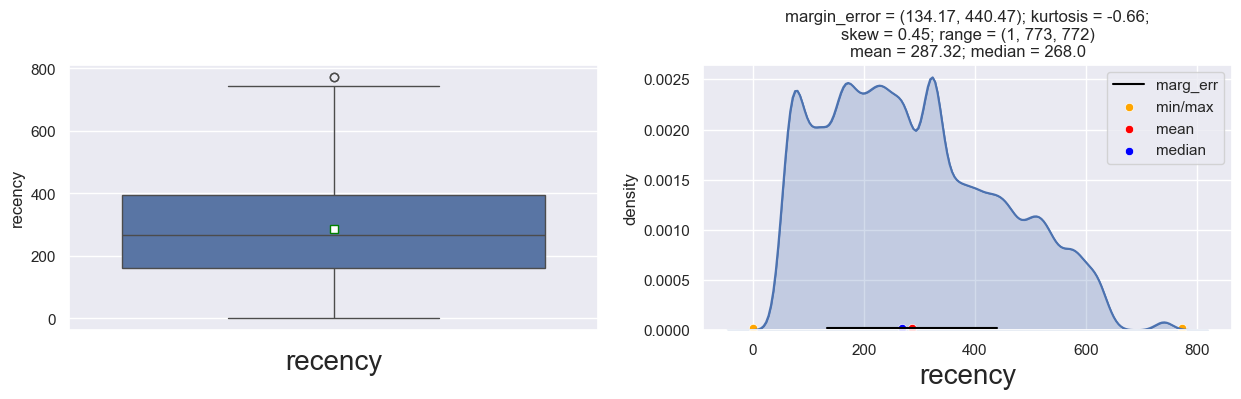

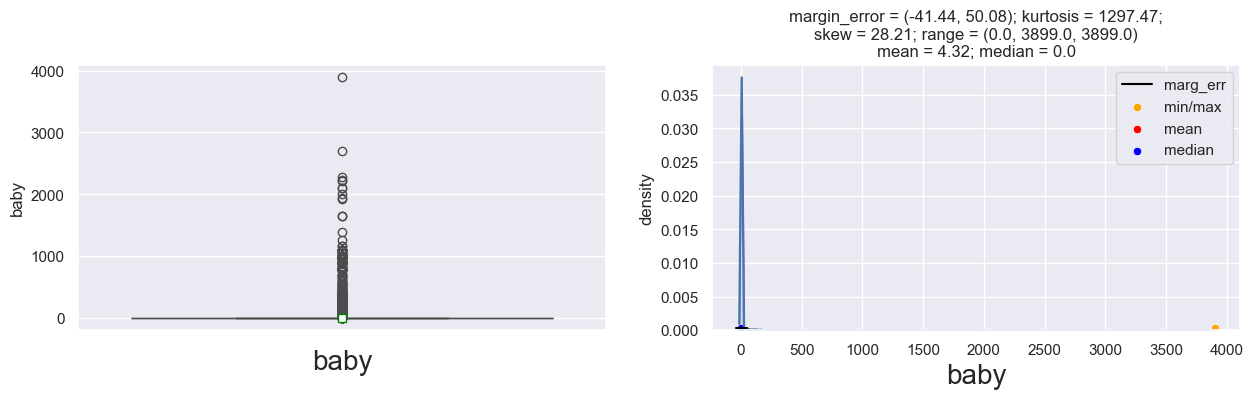

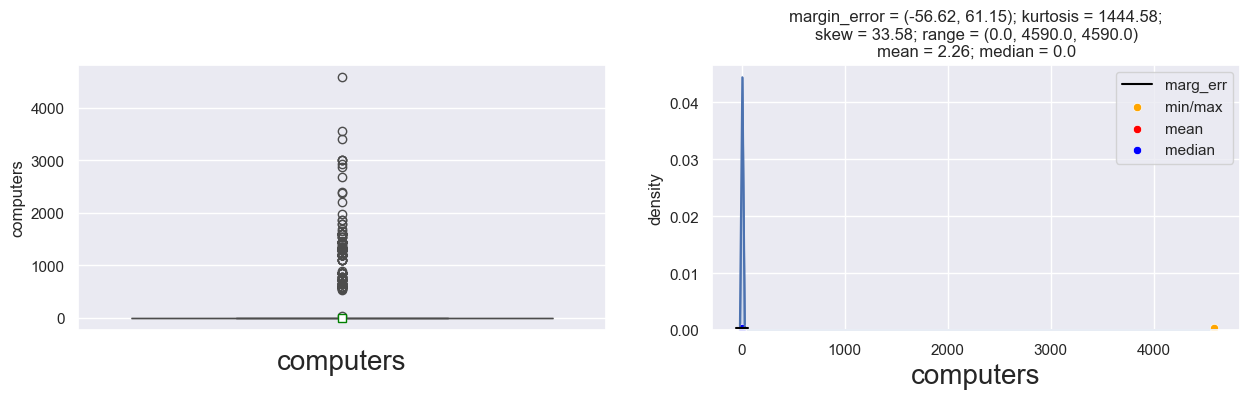

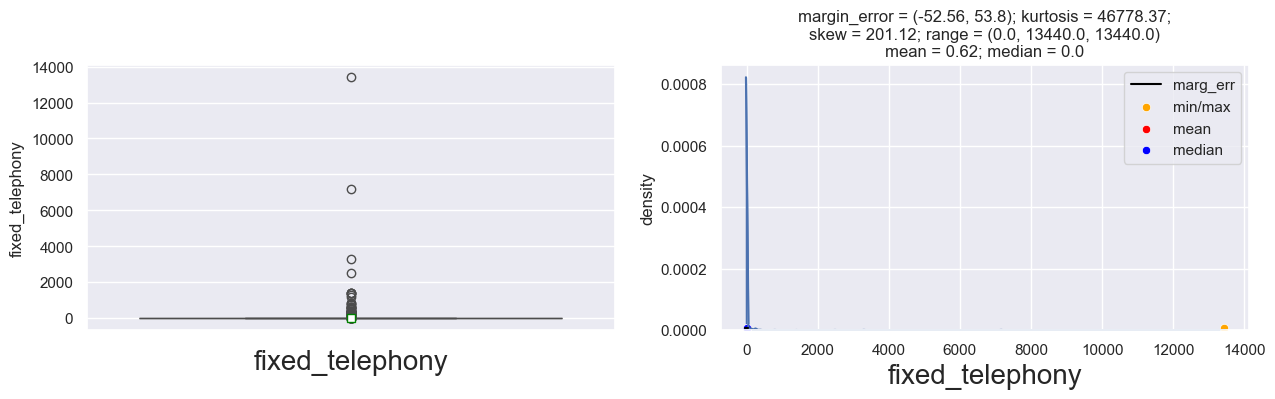

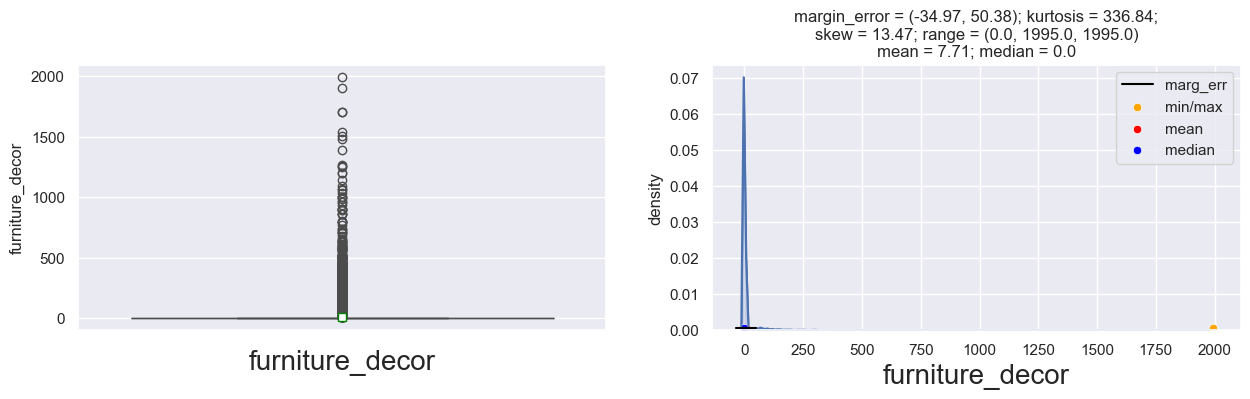

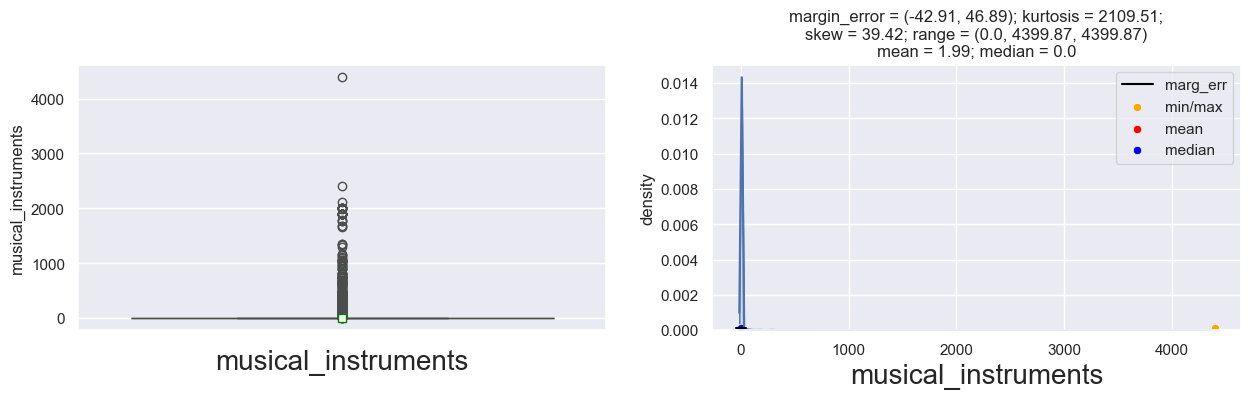

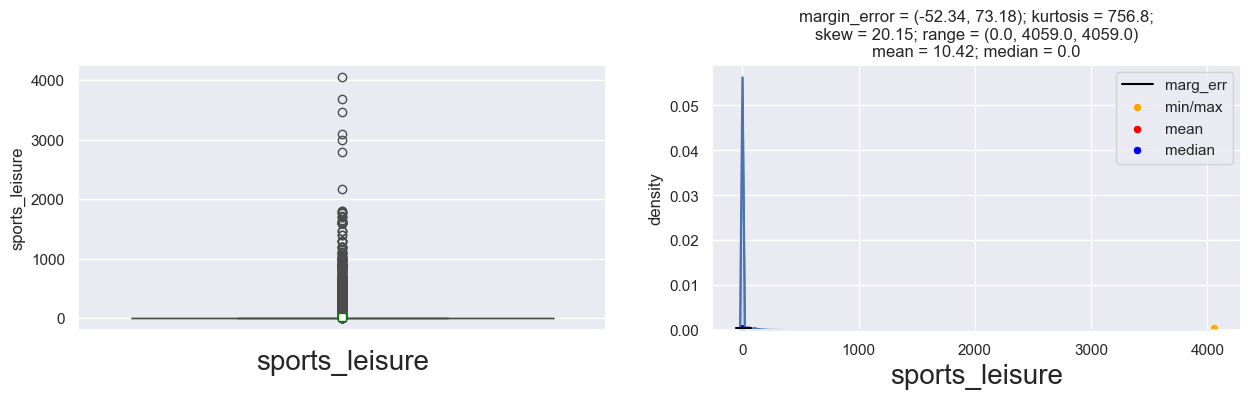

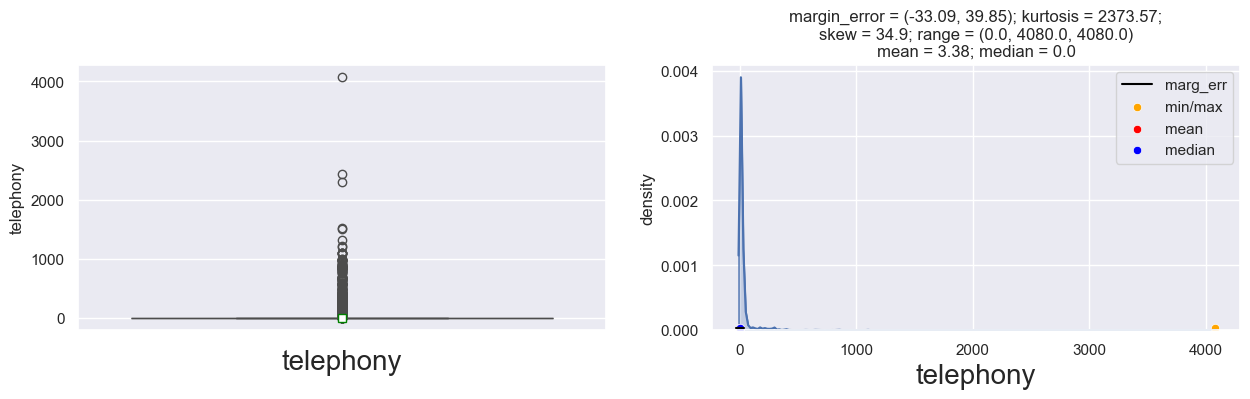

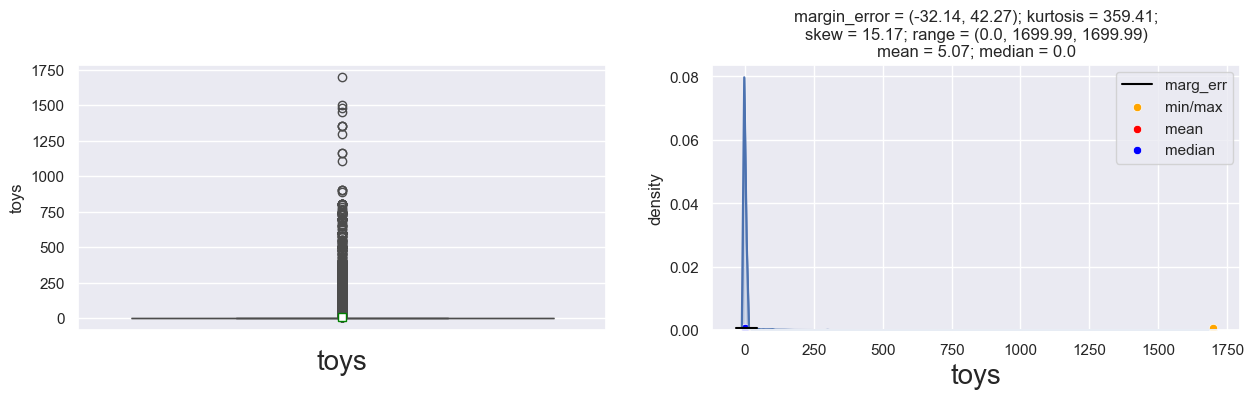

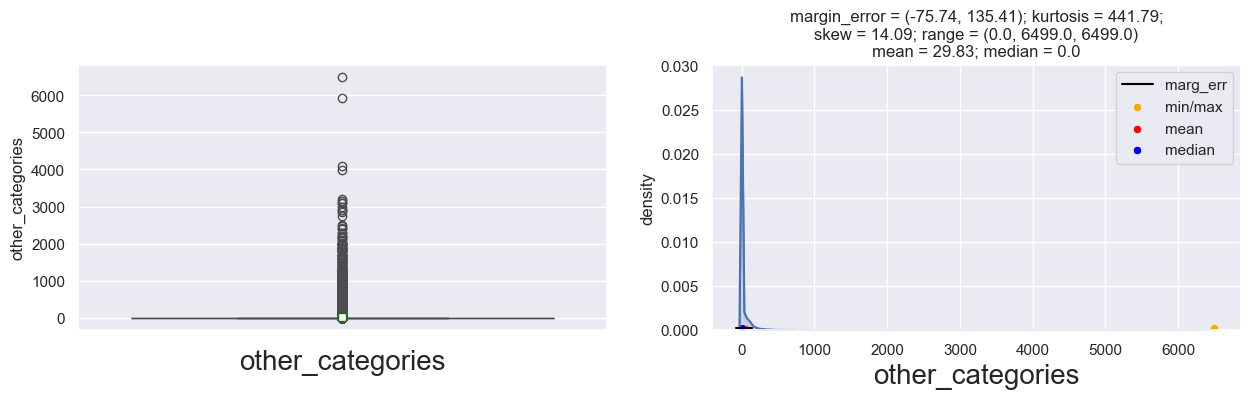

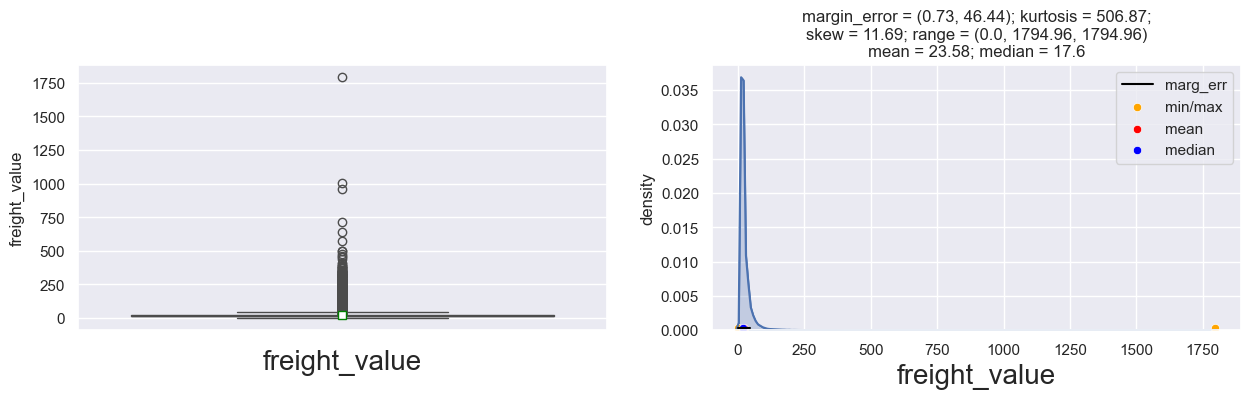

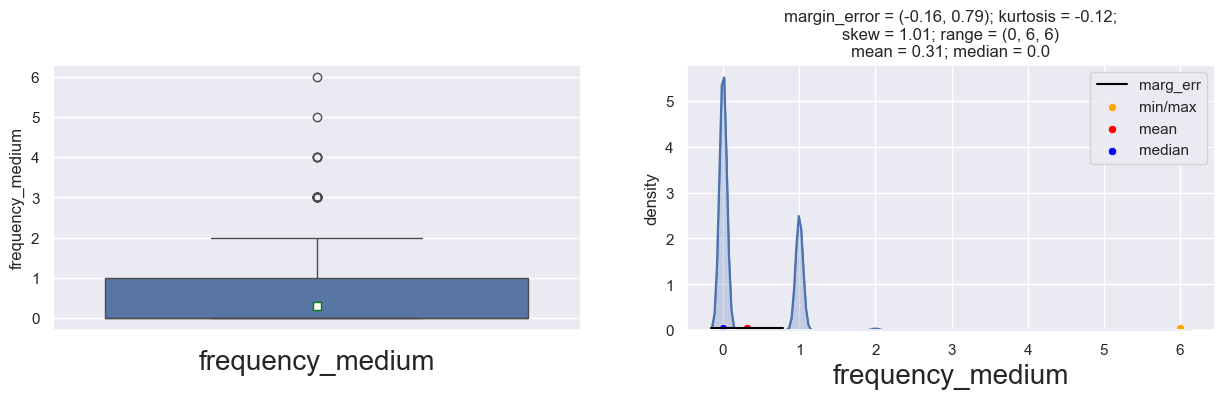

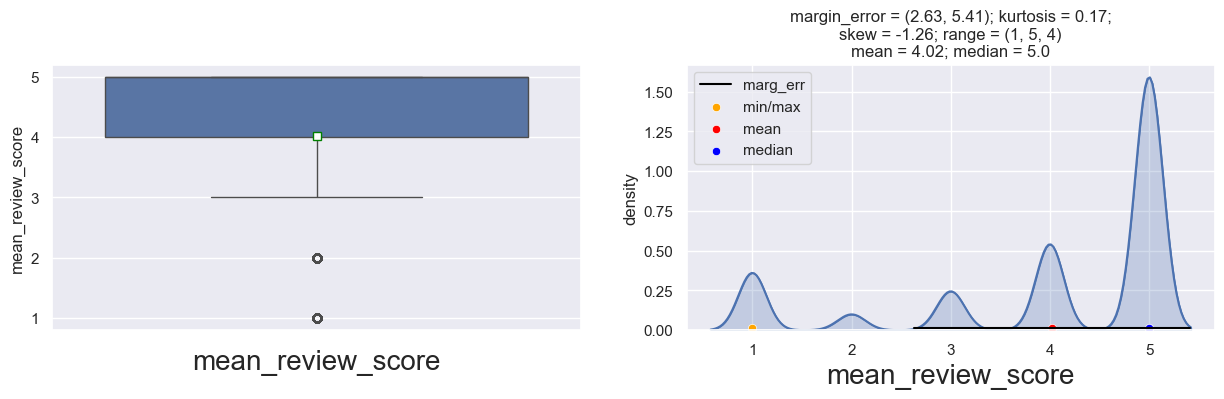

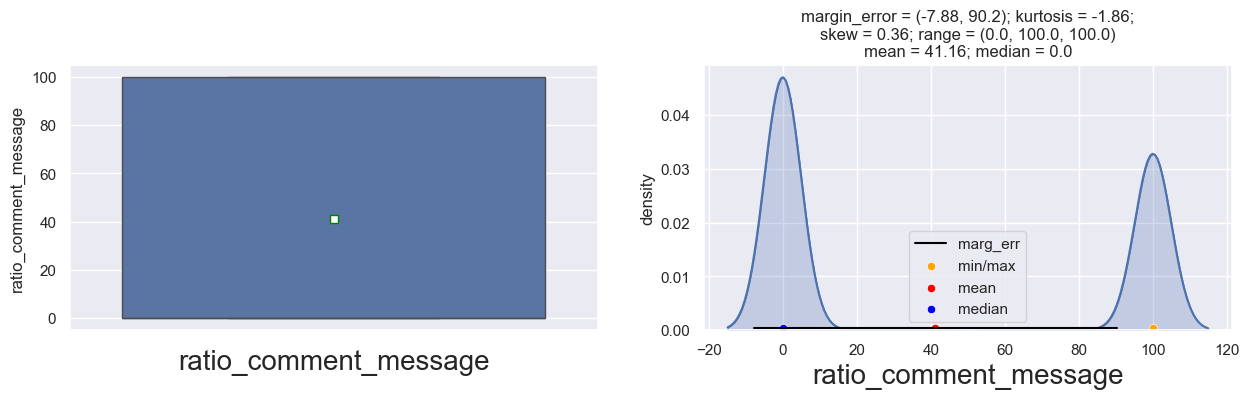

In [313]:
UVA.num_plus(df_reduced, df_reduced.columns)

## reindex + export

In [318]:
df_reduced.shape

(94700, 14)

In [340]:
df_reduced

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,5,0.0
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,4,100.0
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,1,100.0


In [341]:
path = './data/'

df_reduced.to_csv(path + f'{csv_export_name}.csv', index=False)
print(f'export {csv_export_name} finished !')

export customers_2016-09-04_2018-10-17 finished !


In [342]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [343]:
#ls -lh ./data

In [319]:
## method building : error check/catch : only process if elements are numerical values

In [320]:
## todo : clustering sur RFM : kmeans / dbscan